# Feature Selection Methods for Breast Cancer Prediction
## Wisconsin Breast Cancer Diagnostic Dataset (UCI ID: 17)

**Objective:** Reproduce every result from the feature selection report:
- Data overview & exploratory analysis
- Baseline Logistic Regression (all 30 features)
- Univariate methods: Pearson Correlation, ANOVA F-test, Chi-Square, ReliefF
- Multivariate methods: CFS, CON, DISR
- Comparative analysis & conclusions

**Evaluation:** 10-fold stratified cross-validation throughout  
**Model:** Logistic Regression (standardised features, lbfgs solver)


---
## 0. Environment Setup

In [1]:
# Install any missing packages (safe to re-run)
import subprocess, sys

pkgs = ["scikit-learn", "pandas", "numpy", "matplotlib",
        "seaborn", "scipy"]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"],
                   capture_output=True)
print("All packages ready.")


All packages ready.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, KBinsDiscretizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix,
                             roc_curve, ConfusionMatrixDisplay)
from sklearn.feature_selection import chi2, f_classif, mutual_info_classif
from sklearn.metrics import mutual_info_score

np.random.seed(42)

# ── Colour palette (consistent throughout) ────────────────────────────────────
CLR_M    = "#D85A30"   # Malignant  (coral)
CLR_B    = "#1D9E75"   # Benign     (teal)
CLR_BLUE = "#185FA5"
CLR_AMB  = "#BA7517"
CLR_PUR  = "#534AB7"
GRID     = "#e8e8e5"
PALETTE  = [CLR_BLUE, CLR_AMB, "#993556", CLR_PUR,
            CLR_B, "#0F6E56", CLR_M, "#3B6D11"]

# ── Matplotlib defaults ───────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       GRID,
    "grid.linewidth":   0.6,
    "font.family":      "DejaVu Sans",
    "figure.dpi":       110,
})

print("Imports complete.")


Imports complete.


---
## 1. Data Overview

The **Wisconsin Breast Cancer Diagnostic** dataset is loaded directly from
`sklearn.datasets`.  
- 569 samples, 30 numeric features, 0 missing values  
- Target: **1 = Malignant (M)**, **0 = Benign (B)**  
  *(sklearn encodes 0=Malignant by default — we flip so 1=Malignant)*


In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────
bc    = load_breast_cancer()
X     = pd.DataFrame(bc.data, columns=bc.feature_names)
y_raw = pd.Series(bc.target, name="diagnosis")   # sklearn: 0=malignant,1=benign
y     = 1 - y_raw                                 # flip  → 1=Malignant,0=Benign

feature_names = list(X.columns)
df = X.copy()
df["diagnosis"] = y

print(f"Dataset shape : {X.shape}")
print(f"\nClass distribution (1=Malignant, 0=Benign):")
print(y.value_counts().rename({1:"Malignant",0:"Benign"}))
print(f"\nMissing values : {X.isnull().sum().sum()}")
print(f"\nFeature data types:\n{X.dtypes.value_counts()}")


Dataset shape : (569, 30)

Class distribution (1=Malignant, 0=Benign):
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Missing values : 0

Feature data types:
float64    30
Name: count, dtype: int64


In [4]:
# ── Descriptive statistics — mean features ────────────────────────────────────
mean_feats = [c for c in feature_names if c.startswith("mean")]
df[mean_feats].describe().round(3)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097


In [5]:
# ── Descriptive statistics — worst features ───────────────────────────────────
worst_feats = [c for c in feature_names if c.startswith("worst")]
df[worst_feats].describe().round(3)


,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


In [6]:
# ── Descriptive statistics — SE (error) features ─────────────────────────────
se_feats = [c for c in feature_names if "error" in c]
df[se_feats].describe().round(3)


,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,0.405,1.217,2.866,40.337,0.007,0.025,0.032,0.012,0.021,0.004
std,0.277,0.552,2.022,45.491,0.003,0.018,0.030,0.006,0.008,0.003
min,0.112,0.360,0.757,6.802,0.002,0.002,0.000,0.000,0.008,0.001
25%,0.232,0.834,1.606,17.850,0.005,0.013,0.015,0.008,0.015,0.002
50%,0.324,1.108,2.287,24.530,0.006,0.020,0.026,0.011,0.019,0.003
75%,0.479,1.474,3.357,45.190,0.008,0.032,0.042,0.015,0.023,0.005
max,2.873,4.885,21.980,542.200,0.031,0.135,0.396,0.053,0.079,0.030


In [7]:
# ── Feature names reference table ─────────────────────────────────────────────
characteristics = [
    "Radius",          "Texture",         "Perimeter",       "Area",
    "Smoothness",      "Compactness",      "Concavity",       "Concave points",
    "Symmetry",        "Fractal dimension"
]
feat_ref = pd.DataFrame({
    "Characteristic": characteristics,
    "Mean feature":   [f"mean {c.lower()}" for c in characteristics],
    "SE feature":     [f"{c.lower()} error" for c in characteristics],
    "Worst feature":  [f"worst {c.lower()}" for c in characteristics],
})
print("Feature reference table (10 characteristics × 3 statistics = 30 features)")
display(feat_ref)


Feature reference table (10 characteristics × 3 statistics = 30 features)


,Characteristic,Mean feature,SE feature,Worst feature
0,Radius,mean radius,radius error,worst radius
1,Texture,mean texture,texture error,worst texture
2,Perimeter,mean perimeter,perimeter error,worst perimeter
3,Area,mean area,area error,worst area
4,Smoothness,mean smoothness,smoothness error,worst smoothness
5,Compactness,mean compactness,compactness error,worst compactness
6,Concavity,mean concavity,concavity error,worst concavity
7,Concave points,mean concave points,concave points error,worst concave points
8,Symmetry,mean symmetry,symmetry error,worst symmetry
9,Fractal dimension,mean fractal dimension,fractal dimension error,worst fractal dimension


---
## 2. Exploratory Data Analysis

### 2.1 Class Distribution


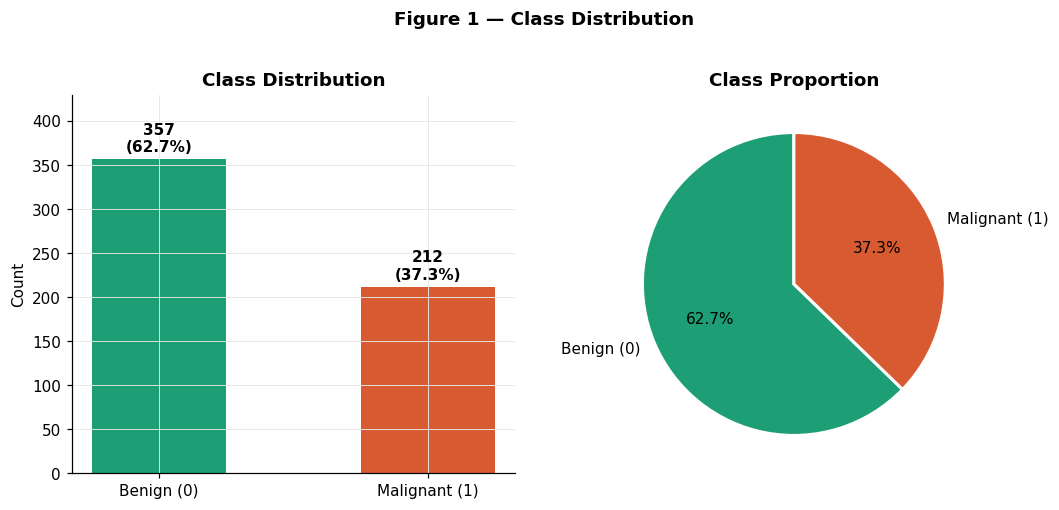


Class balance ratio (Benign:Malignant) = 357:212 = 1.68:1


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

counts = y.value_counts().sort_index()
labs   = ["Benign (0)", "Malignant (1)"]
cols   = [CLR_B, CLR_M]

bars = axes[0].bar(labs, [counts[0], counts[1]], color=cols, width=0.5)
for bar, cnt in zip(bars, [counts[0], counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f"{cnt}\n({cnt/len(y)*100:.1f}%)",
                 ha="center", va="bottom", fontweight="bold")
axes[0].set_ylim(0, 430)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

axes[1].pie([counts[0], counts[1]], labels=labs, colors=cols,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Class Proportion", fontweight="bold")

plt.suptitle("Figure 1 — Class Distribution", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nClass balance ratio (Benign:Malignant) = {counts[0]}:{counts[1]}"
      f" = {counts[0]/counts[1]:.2f}:1")


### 2.2 Univariate Distributions — Mean Features

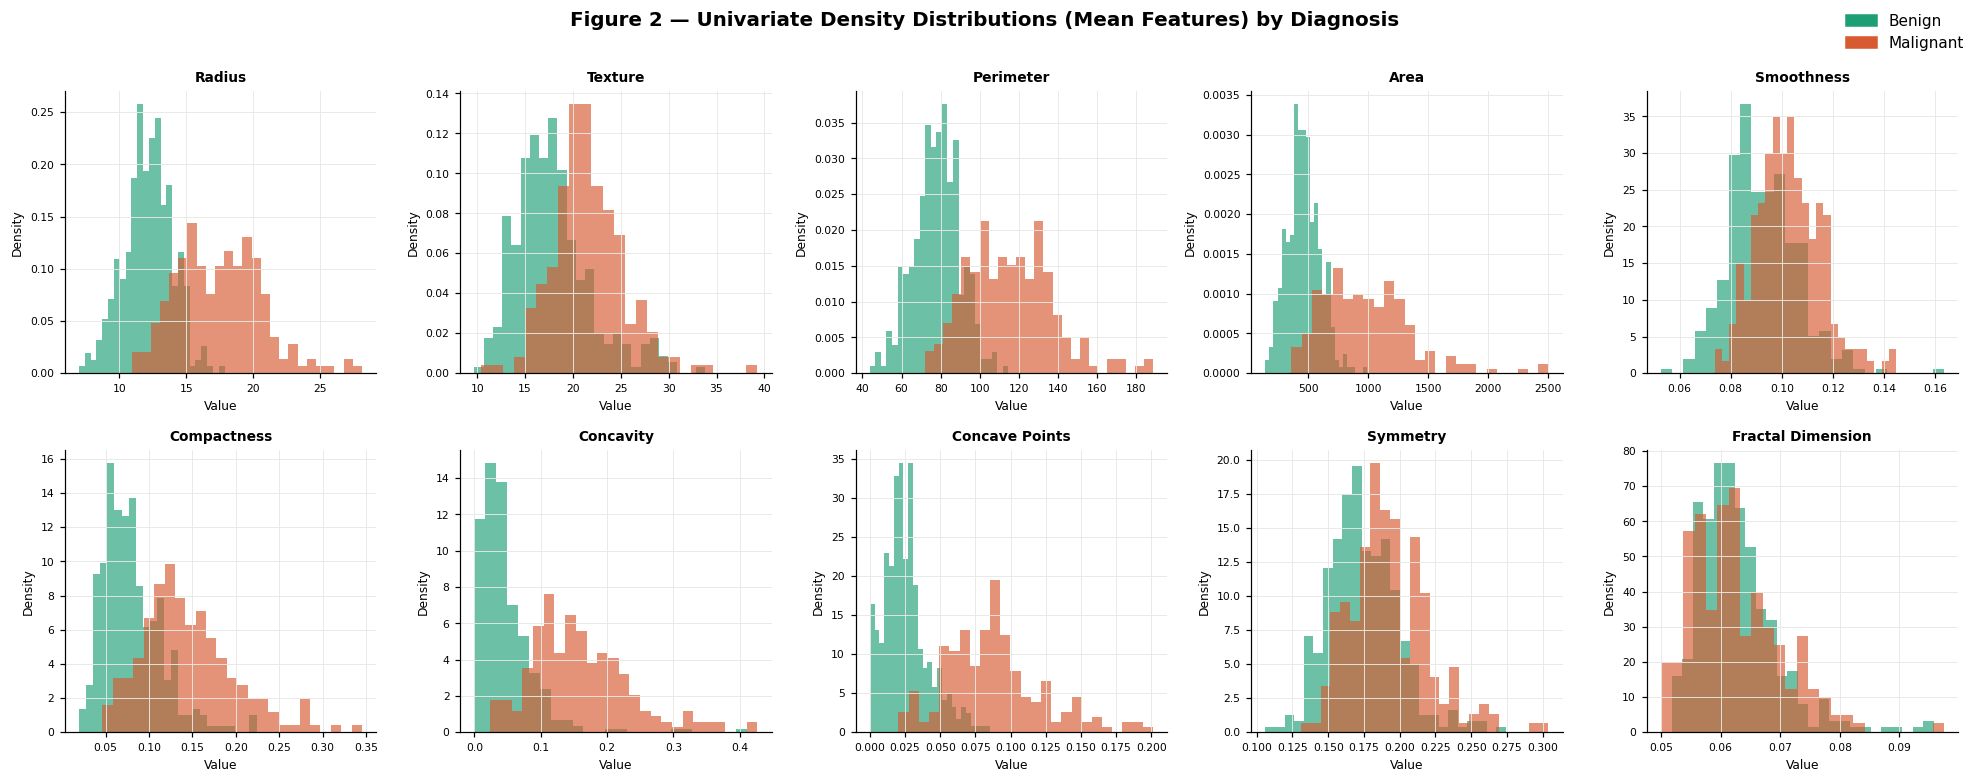

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Figure 2 — Univariate Density Distributions (Mean Features) by Diagnosis",
             fontsize=13, fontweight="bold", y=1.01)

for ax, feat in zip(axes.flatten(), mean_feats):
    benign    = X.loc[y==0, feat]
    malignant = X.loc[y==1, feat]
    ax.hist(benign,    bins=25, color=CLR_B, alpha=0.65, label="Benign",    density=True)
    ax.hist(malignant, bins=25, color=CLR_M, alpha=0.65, label="Malignant", density=True)
    ax.set_title(feat.replace("mean ","").title(), fontsize=9, fontweight="bold")
    ax.set_xlabel("Value", fontsize=8)
    ax.set_ylabel("Density", fontsize=8)
    ax.tick_params(labelsize=7)

handles = [mpatches.Patch(color=CLR_B, label="Benign"),
           mpatches.Patch(color=CLR_M, label="Malignant")]
fig.legend(handles=handles, loc="upper right", fontsize=10, frameon=False)
plt.tight_layout()
plt.show()


### 2.3 Bivariate Analysis — Boxplots of Top Features

We rank features by their individual AUC (one-feature logistic regression) and plot
the top 10 as box plots.


In [10]:
# Compute per-feature AUC (individual discriminative power)
aucs = {}
for c in feature_names:
    a = roc_auc_score(y, X[c])
    aucs[c] = max(a, 1 - a)   # ensure AUC ≥ 0.5

top10_auc = sorted(aucs, key=aucs.get, reverse=True)[:10]
print("Top 10 features by individual AUC:")
for i, f in enumerate(top10_auc, 1):
    print(f"  {i:2d}. {f:<30s}  AUC = {aucs[f]:.4f}")


Top 10 features by individual AUC:
   1. worst perimeter                 AUC = 0.9755
   2. worst radius                    AUC = 0.9704
   3. worst area                      AUC = 0.9698
   4. worst concave points            AUC = 0.9667
   5. mean concave points             AUC = 0.9644
   6. mean perimeter                  AUC = 0.9469
   7. mean area                       AUC = 0.9383
   8. mean concavity                  AUC = 0.9378
   9. mean radius                     AUC = 0.9375
  10. area error                      AUC = 0.9264


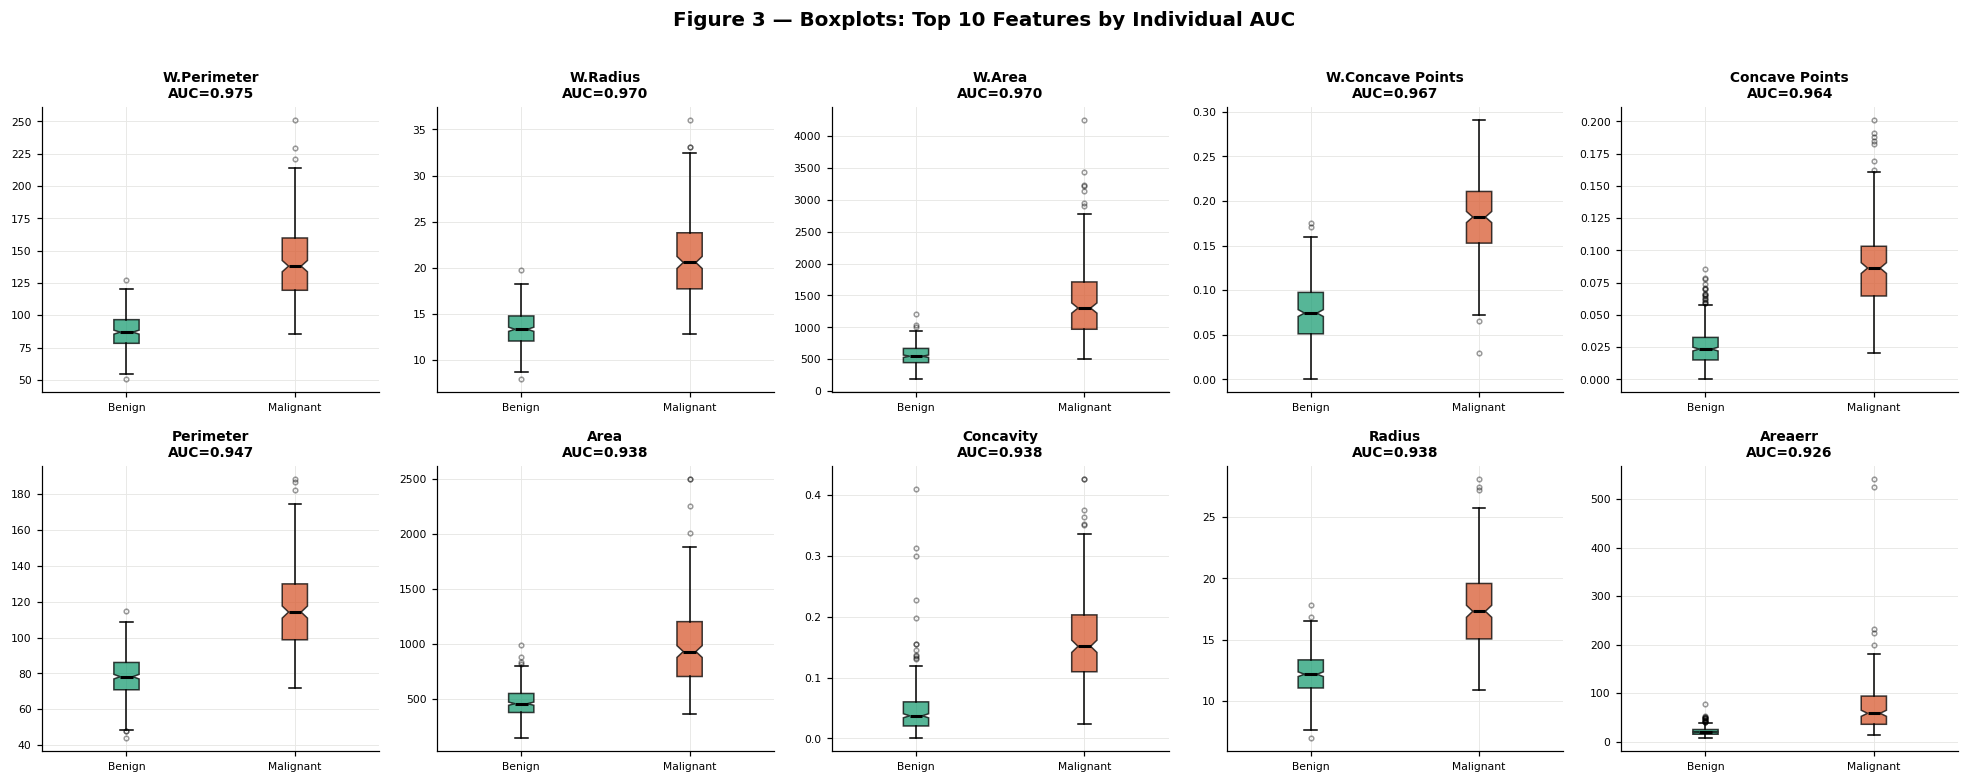

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Figure 3 — Boxplots: Top 10 Features by Individual AUC",
             fontsize=13, fontweight="bold", y=1.01)

for ax, feat in zip(axes.flatten(), top10_auc):
    data_b = X.loc[y==0, feat]
    data_m = X.loc[y==1, feat]
    bp = ax.boxplot([data_b, data_m], patch_artist=True, notch=True,
                    medianprops={"color":"black","linewidth":2},
                    whiskerprops={"linewidth":1}, capprops={"linewidth":1},
                    flierprops={"marker":"o","markersize":3,"alpha":0.4})
    bp["boxes"][0].set_facecolor(CLR_B); bp["boxes"][0].set_alpha(0.75)
    bp["boxes"][1].set_facecolor(CLR_M); bp["boxes"][1].set_alpha(0.75)
    ax.set_xticklabels(["Benign","Malignant"], fontsize=8)
    short = feat.replace("mean ","").replace("worst ","w.").replace(" error","err").title()
    ax.set_title(f"{short}\nAUC={aucs[feat]:.3f}", fontsize=9, fontweight="bold")
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


### 2.4 Bivariate Scatter Plots — Key Feature Pairs

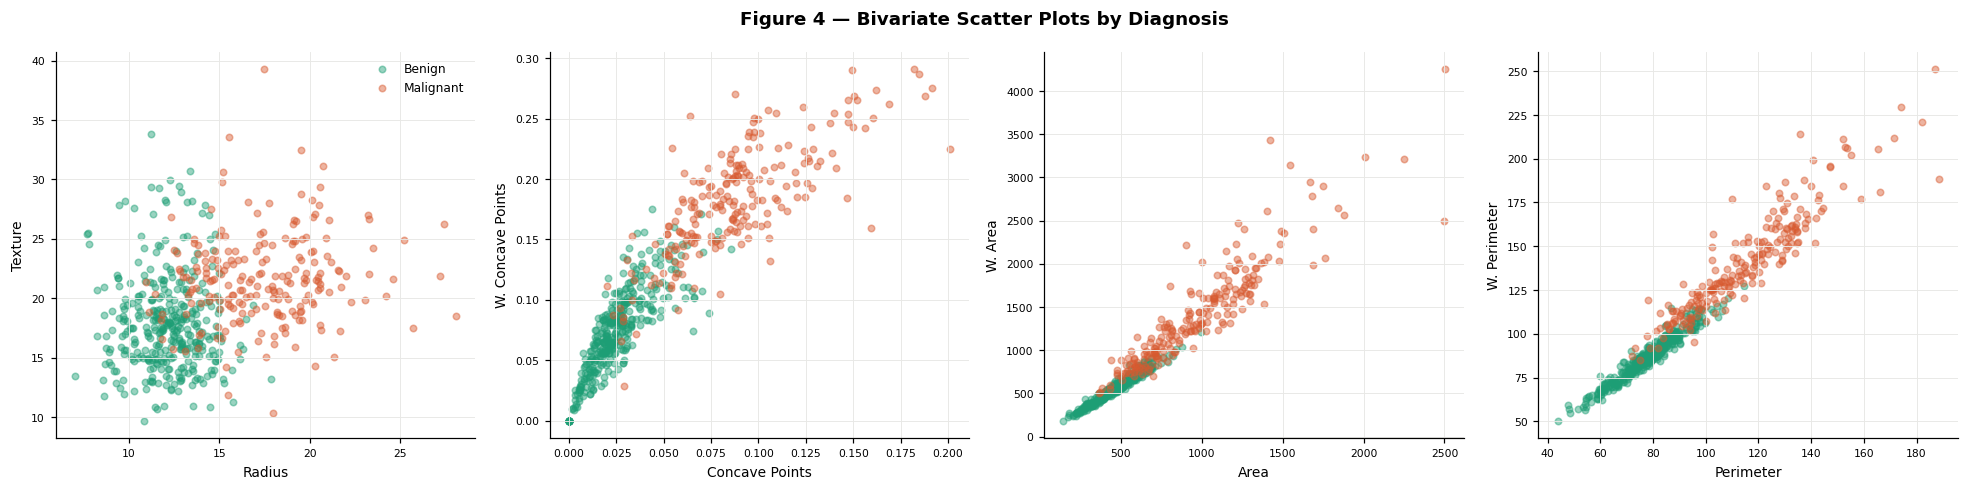

In [12]:
pairs = [("mean radius",       "mean texture"),
         ("mean concave points","worst concave points"),
         ("mean area",          "worst area"),
         ("mean perimeter",     "worst perimeter")]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
fig.suptitle("Figure 4 — Bivariate Scatter Plots by Diagnosis",
             fontsize=12, fontweight="bold")

for ax, (fx, fy) in zip(axes, pairs):
    for cls, clr, lbl in [(0, CLR_B, "Benign"), (1, CLR_M, "Malignant")]:
        mask = y == cls
        ax.scatter(X.loc[mask, fx], X.loc[mask, fy],
                   c=clr, alpha=0.45, s=18, label=lbl)
    ax.set_xlabel(fx.replace("mean ","").replace("worst ","w. ").title(), fontsize=9)
    ax.set_ylabel(fy.replace("mean ","").replace("worst ","w. ").title(), fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


### 2.5 Feature Correlation Heatmap

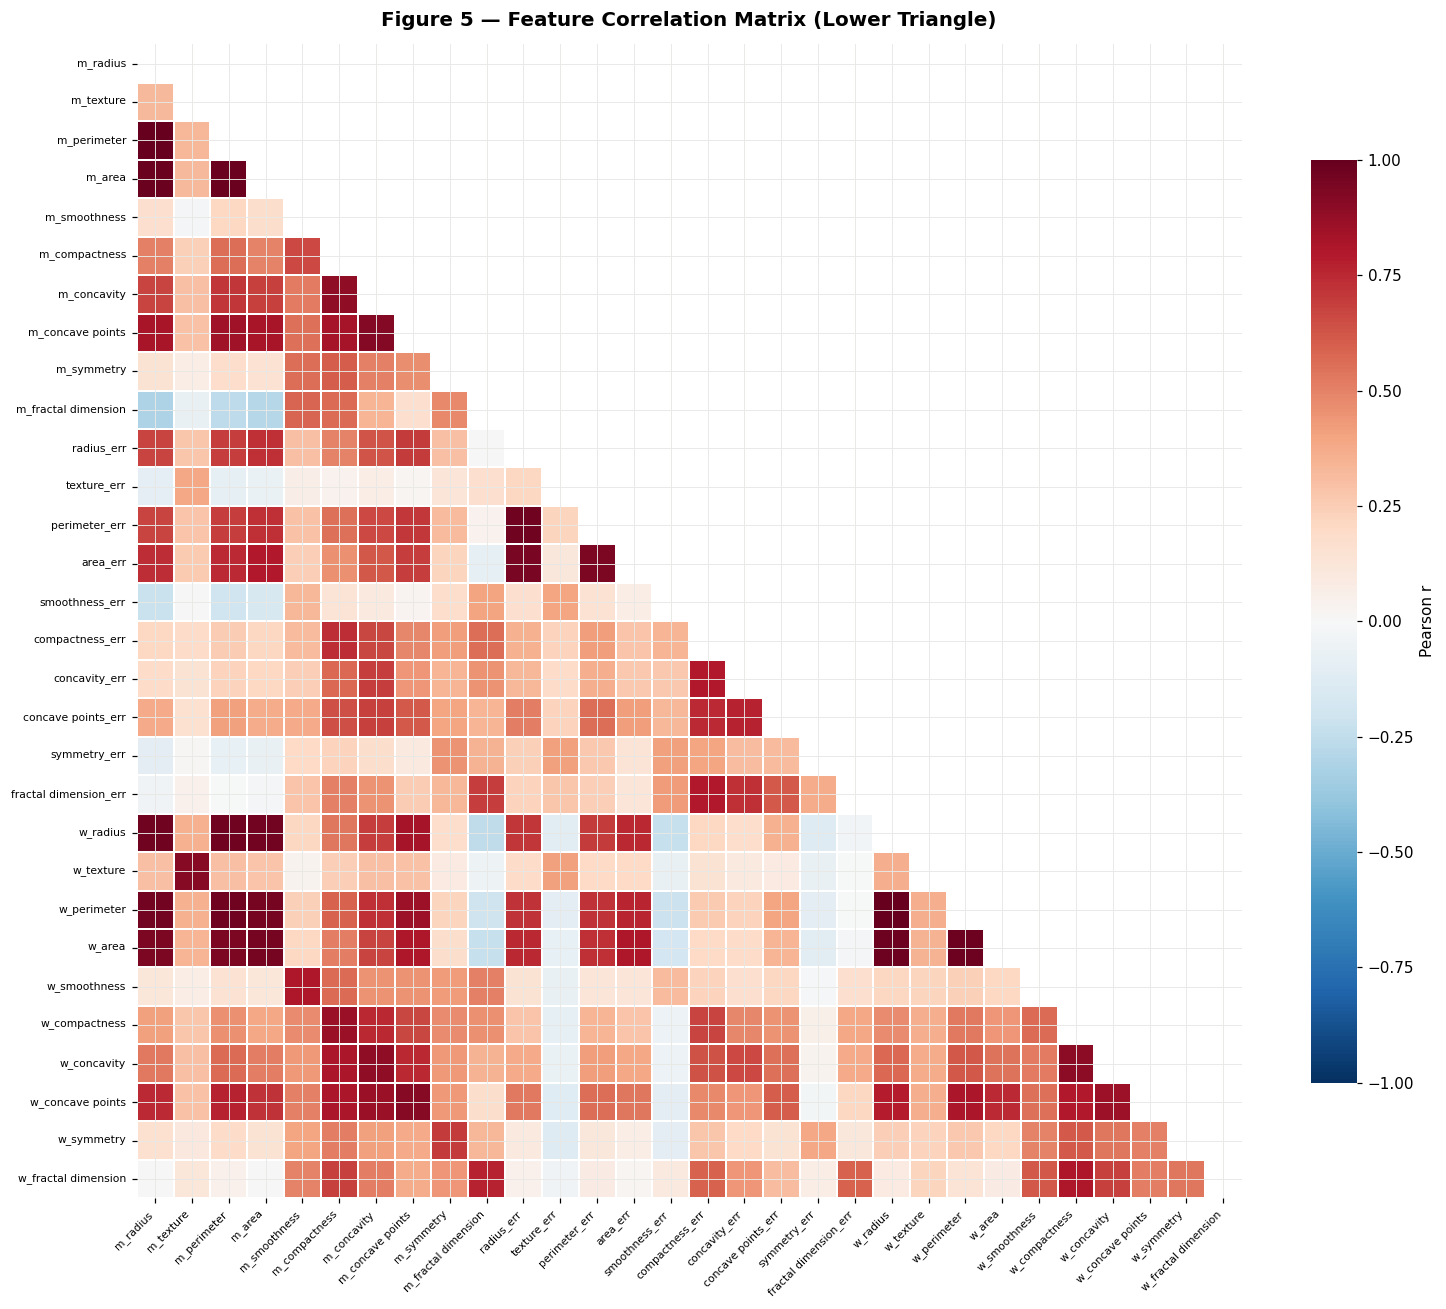


Highly correlated feature pairs (|r| > 0.95):
  mean radius                  ↔  mean perimeter                r = 0.9979
  worst radius                 ↔  worst perimeter               r = 0.9937
  mean radius                  ↔  mean area                     r = 0.9874
  mean perimeter               ↔  mean area                     r = 0.9865
  worst radius                 ↔  worst area                    r = 0.9840
  worst perimeter              ↔  worst area                    r = 0.9776
  radius error                 ↔  perimeter error               r = 0.9728
  mean perimeter               ↔  worst perimeter               r = 0.9704
  mean radius                  ↔  worst radius                  r = 0.9695
  mean perimeter               ↔  worst radius                  r = 0.9695
  mean radius                  ↔  worst perimeter               r = 0.9651
  mean area                    ↔  worst radius                  r = 0.9627
  mean area                    ↔  worst area         

In [13]:
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle masked

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Pearson r", "shrink": 0.8}, ax=ax)

short_names = [c.replace("mean ","m_").replace("worst ","w_")
                .replace(" error","_err") for c in feature_names]
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(short_names, rotation=0, fontsize=7)
ax.set_title("Figure 5 — Feature Correlation Matrix (Lower Triangle)",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# Print highly correlated pairs (|r| > 0.95)
print("\nHighly correlated feature pairs (|r| > 0.95):")
high = []
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        r = corr.iloc[i, j]
        if abs(r) > 0.95:
            high.append((feature_names[i], feature_names[j], r))
high.sort(key=lambda x: abs(x[2]), reverse=True)
for f1, f2, r in high:
    print(f"  {f1:<28s} ↔  {f2:<28s}  r = {r:.4f}")
print(f"\nTotal pairs with |r| > 0.95: {len(high)}")


---
## 3. Baseline Model — Logistic Regression (All 30 Features)

**Setup:**
- Features are standardised (zero mean, unit variance) inside each CV fold to prevent leakage
- 10-fold stratified cross-validation
- Solver: `lbfgs`, `max_iter=5000`


In [14]:
# ── Shared evaluation function (used throughout the notebook) ─────────────────
def evaluate_lr(X_in, y_in, label="Model", cv=10, verbose=True):
    """
    Fit Logistic Regression inside 10-fold CV.
    Standardisation is applied *inside* the pipeline using each fold's
    training data statistics → no data leakage.
    Returns a dict with all metrics.
    """
    from sklearn.pipeline import Pipeline

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("lr",     LogisticRegression(max_iter=5000, random_state=42,
                                      solver="lbfgs"))
    ])
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    res = cross_validate(pipe, X_in, y_in, cv=skf,
                         scoring=["accuracy","precision","recall","f1","roc_auc"],
                         return_train_score=False)
    out = {
        "Model":     label,
        "N_features": X_in.shape[1],
        "Accuracy":  res["test_accuracy"].mean(),
        "Precision": res["test_precision"].mean(),
        "Recall":    res["test_recall"].mean(),
        "F1":        res["test_f1"].mean(),
        "AUC":       res["test_roc_auc"].mean(),
        "Acc_std":   res["test_accuracy"].std(),
        "AUC_std":   res["test_roc_auc"].std(),
    }
    if verbose:
        print(f"{'─'*60}")
        print(f"  {label}")
        print(f"  Features  : {out['N_features']}")
        print(f"  Accuracy  : {out['Accuracy']:.4f}  (±{out['Acc_std']:.4f})")
        print(f"  Precision : {out['Precision']:.4f}")
        print(f"  Recall    : {out['Recall']:.4f}")
        print(f"  F1        : {out['F1']:.4f}")
        print(f"  AUC       : {out['AUC']:.4f}  (±{out['AUC_std']:.4f})")
    return out

print("evaluate_lr() helper defined.")


evaluate_lr() helper defined.


In [15]:
# ── Baseline: all 30 features ─────────────────────────────────────────────────
baseline = evaluate_lr(X, y, label="Baseline (All 30 features)")
all_results = [baseline]


────────────────────────────────────────────────────────────
  Baseline (All 30 features)
  Features  : 30
  Accuracy  : 0.9754  (±0.0195)
  Precision : 0.9820
  Recall    : 0.9526
  F1        : 0.9659
  AUC       : 0.9947  (±0.0065)


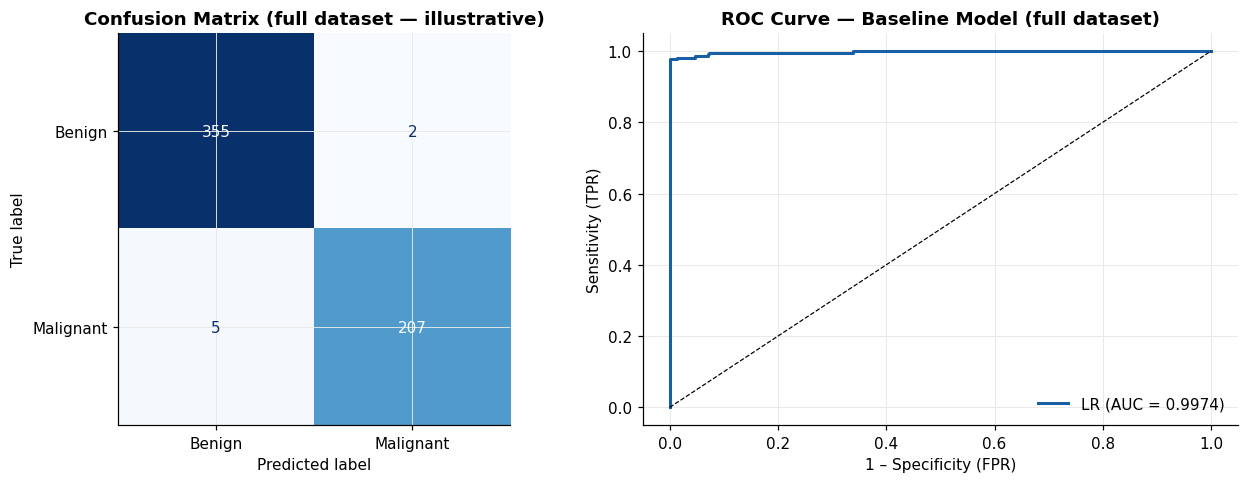


Note: CV results are the authoritative performance measure.
CV Accuracy: 0.9754  |  CV AUC: 0.9947


In [16]:
# ── Confusion matrix & ROC on the full training set (for illustration) ────────
from sklearn.pipeline import Pipeline

pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("lr",     LogisticRegression(max_iter=5000, random_state=42, solver="lbfgs"))
])

# Train on full data for illustration only (CV is the proper evaluation)
pipe_full.fit(X, y)
y_pred  = pipe_full.predict(X)
y_proba = pipe_full.predict_proba(X)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Confusion matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Benign","Malignant"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (full dataset — illustrative)", fontweight="bold")

# ROC curve
fpr, tpr, _ = roc_curve(y, y_proba)
axes[1].plot(fpr, tpr, color=CLR_BLUE, lw=2,
             label=f"LR (AUC = {roc_auc_score(y, y_proba):.4f})")
axes[1].plot([0,1],[0,1],"k--", lw=0.8)
axes[1].set_xlabel("1 – Specificity (FPR)"); axes[1].set_ylabel("Sensitivity (TPR)")
axes[1].set_title("ROC Curve — Baseline Model (full dataset)", fontweight="bold")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print("\nNote: CV results are the authoritative performance measure.")
print(f"CV Accuracy: {baseline['Accuracy']:.4f}  |  CV AUC: {baseline['AUC']:.4f}")


---
## 4. Univariate Feature Selection Methods

Each method evaluates features independently against the target.
We select the **top 10 features** from each method and re-train Logistic Regression.


### 4.1 Pearson Correlation

**Formula:**  
$$r(X_j, Y) = \frac{\sum_i (X_{ji} - \bar{X}_j)(Y_i - \bar{Y})}{\sqrt{\sum_i (X_{ji} - \bar{X}_j)^2 \cdot \sum_i (Y_i - \bar{Y})^2}}$$

Features ranked by $|r|$.  Higher = stronger linear association with target.


In [17]:
# ── Pearson |r| with target ───────────────────────────────────────────────────
pearson_scores = {}
for feat in feature_names:
    r, p = stats.pearsonr(X[feat], y)
    pearson_scores[feat] = {"r": r, "abs_r": abs(r), "p_value": p}

pearson_df = (pd.DataFrame(pearson_scores).T
                .astype(float)
                .sort_values("abs_r", ascending=False)
                .reset_index()
                .rename(columns={"index": "feature"}))

print("Top 15 features by Pearson |r| with target:")
display(pearson_df.head(15)[["feature","r","abs_r","p_value"]].round(6))


Top 15 features by Pearson |r| with target:


,feature,r,abs_r,p_value
0,worst concave points,0.793566,0.793566,0.0
1,worst perimeter,0.782914,0.782914,0.0
2,mean concave points,0.776614,0.776614,0.0
3,worst radius,0.776454,0.776454,0.0
4,mean perimeter,0.742636,0.742636,0.0
5,worst area,0.733825,0.733825,0.0
6,mean radius,0.730029,0.730029,0.0
7,mean area,0.708984,0.708984,0.0
8,mean concavity,0.696360,0.696360,0.0
9,worst concavity,0.659610,0.659610,0.0


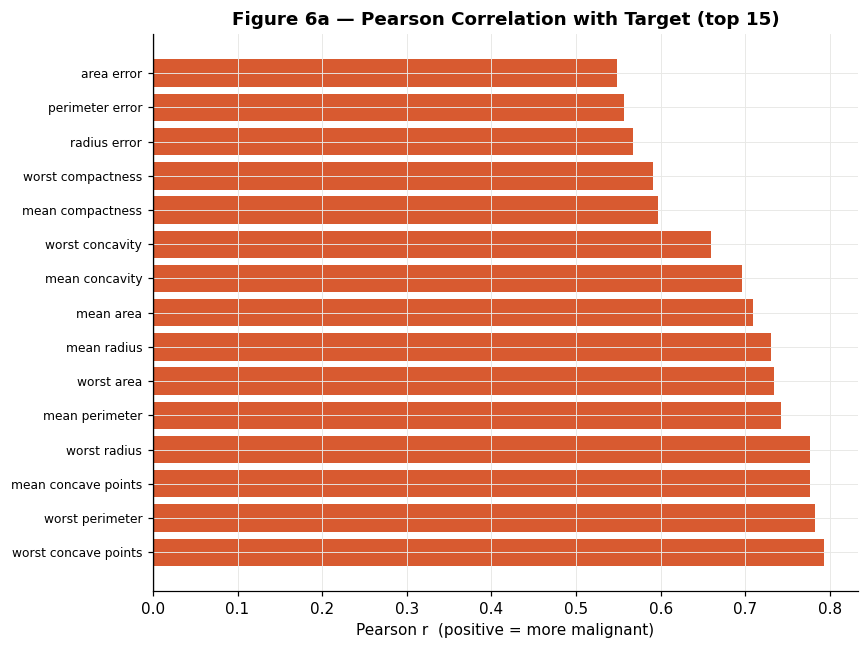

In [18]:
# Visualise
fig, ax = plt.subplots(figsize=(8, 6))
top15 = pearson_df.head(15)
colors_bar = [CLR_M if r > 0 else CLR_B for r in top15["r"]]
bars = ax.barh(range(15), top15["r"].values[::-1], color=colors_bar[::-1])
ax.set_yticks(range(15))
ax.set_yticklabels(top15["feature"].values[::-1], fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r  (positive = more malignant)")
ax.set_title("Figure 6a — Pearson Correlation with Target (top 15)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [19]:
# ── Model with top-10 Pearson features ───────────────────────────────────────
top10_pearson = pearson_df.head(10)["feature"].tolist()
print("Selected features:", top10_pearson)
res_pearson = evaluate_lr(X[top10_pearson], y, "Pearson (top 10)")
all_results.append(res_pearson)


Selected features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity']
────────────────────────────────────────────────────────────
  Pearson (top 10)
  Features  : 10
  Accuracy  : 0.9561  (±0.0386)
  Precision : 0.9471
  Recall    : 0.9335
  F1        : 0.9387
  AUC       : 0.9884  (±0.0156)


### 4.2 ANOVA F-Test (t-test for binary targets)

**Formula:**  
$$F = \frac{\text{Between-group variance}}{\text{Within-group variance}} = \frac{n_0(\bar{x}_0 - \bar{x})^2 + n_1(\bar{x}_1 - \bar{x})^2}{\sum_i(x_i - \bar{x}_k)^2 / (n-2)}$$

`sklearn.feature_selection.f_classif` is applied to standardised features.


In [20]:
# ── ANOVA F-test ──────────────────────────────────────────────────────────────
scaler_tmp = StandardScaler()
X_sc       = pd.DataFrame(scaler_tmp.fit_transform(X), columns=feature_names)

f_scores, f_pvals = f_classif(X_sc, y)
anova_df = (pd.DataFrame({"feature": feature_names,
                           "f_score": f_scores,
                           "p_value": f_pvals})
              .sort_values("f_score", ascending=False)
              .reset_index(drop=True))

print("Top 15 features by ANOVA F-statistic:")
display(anova_df.head(15).round(4))


Top 15 features by ANOVA F-statistic:


,feature,f_score,p_value
0,worst concave points,964.3854,0.0
1,worst perimeter,897.9442,0.0
2,mean concave points,861.6760,0.0
3,worst radius,860.7817,0.0
4,mean perimeter,697.2353,0.0
5,worst area,661.6002,0.0
6,mean radius,646.9810,0.0
7,mean area,573.0607,0.0
8,mean concavity,533.7931,0.0
9,worst concavity,436.6919,0.0


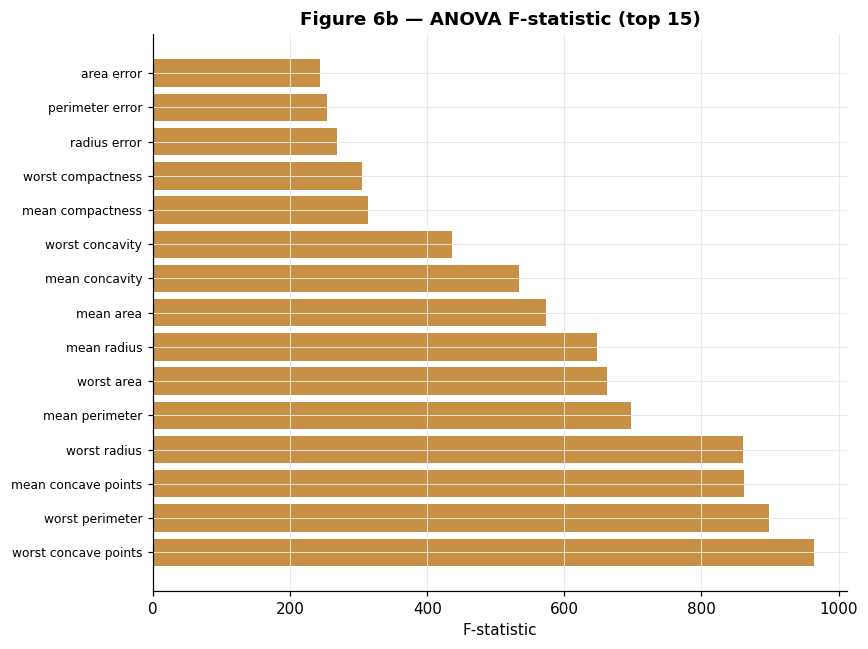

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
top15_a = anova_df.head(15)
ax.barh(range(15), top15_a["f_score"].values[::-1], color=CLR_AMB, alpha=0.8)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_a["feature"].values[::-1], fontsize=8)
ax.set_xlabel("F-statistic")
ax.set_title("Figure 6b — ANOVA F-statistic (top 15)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [22]:
top10_anova = anova_df.head(10)["feature"].tolist()
print("Selected features:", top10_anova)

# Check overlap with Pearson
overlap_pa = set(top10_pearson) & set(top10_anova)
print(f"\nOverlap with Pearson top 10: {len(overlap_pa)}/10 features")
print("Same set?", set(top10_pearson) == set(top10_anova))

res_anova = evaluate_lr(X[top10_anova], y, "ANOVA (top 10)")
all_results.append(res_anova)


Selected features: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean radius', 'mean area', 'mean concavity', 'worst concavity']

Overlap with Pearson top 10: 10/10 features
Same set? True
────────────────────────────────────────────────────────────
  ANOVA (top 10)
  Features  : 10
  Accuracy  : 0.9561  (±0.0386)
  Precision : 0.9471
  Recall    : 0.9335
  F1        : 0.9387
  AUC       : 0.9884  (±0.0156)


### 4.3 Chi-Square Test

**Formula:**  
$$\chi^2 = \sum \frac{(\text{Observed} - \text{Expected})^2}{\text{Expected}}$$

Requires **non-negative** inputs → features scaled to $[0, 1]$ via Min-Max normalisation.


In [23]:
# ── Chi-Square ────────────────────────────────────────────────────────────────
mms    = MinMaxScaler()
X_mm   = mms.fit_transform(X)   # scale to [0,1] for chi2

chi2_scores, chi2_pvals = chi2(X_mm, y)
chi2_df = (pd.DataFrame({"feature":  feature_names,
                          "chi2_score": chi2_scores,
                          "p_value":  chi2_pvals})
             .sort_values("chi2_score", ascending=False)
             .reset_index(drop=True))

print("Top 15 features by Chi-Square score:")
display(chi2_df.head(15).round(4))


Top 15 features by Chi-Square score:


,feature,chi2_score,p_value
0,mean concave points,52.4057,0.0000
1,worst concave points,46.3416,0.0000
2,mean concavity,46.1864,0.0000
3,worst area,35.0439,0.0000
4,worst perimeter,34.4381,0.0000
5,worst radius,34.1249,0.0000
6,worst concavity,31.5630,0.0000
7,mean area,29.3286,0.0000
8,mean perimeter,26.5289,0.0000
9,mean radius,24.8973,0.0000


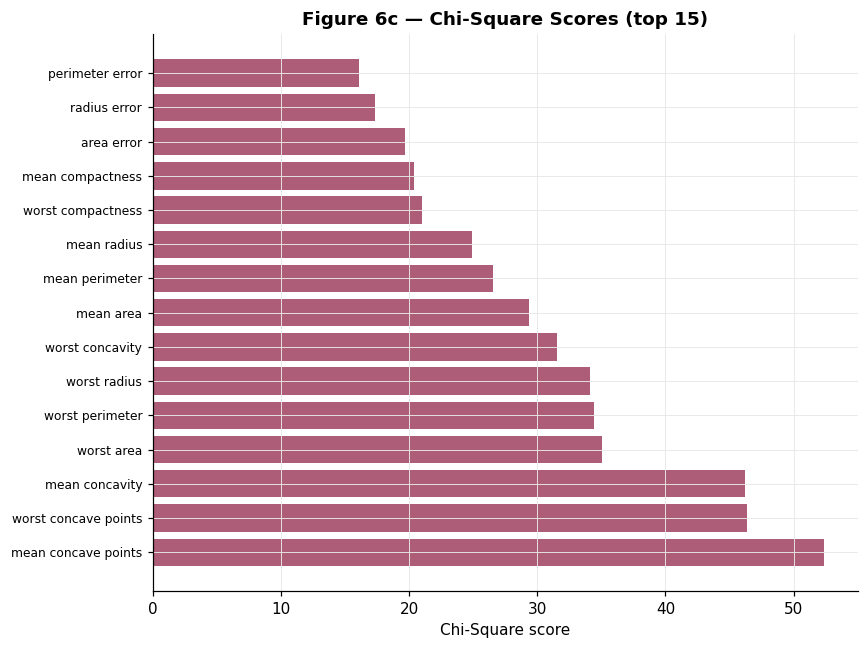

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
top15_c = chi2_df.head(15)
ax.barh(range(15), top15_c["chi2_score"].values[::-1], color="#993556", alpha=0.8)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_c["feature"].values[::-1], fontsize=8)
ax.set_xlabel("Chi-Square score")
ax.set_title("Figure 6c — Chi-Square Scores (top 15)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [25]:
top10_chi2 = chi2_df.head(10)["feature"].tolist()
print("Selected features:", top10_chi2)
print("Same as Pearson?", set(top10_chi2) == set(top10_pearson))
print("Same as ANOVA? ",  set(top10_chi2) == set(top10_anova))

res_chi2 = evaluate_lr(X[top10_chi2], y, "Chi-Square (top 10)")
all_results.append(res_chi2)


Selected features: ['mean concave points', 'worst concave points', 'mean concavity', 'worst area', 'worst perimeter', 'worst radius', 'worst concavity', 'mean area', 'mean perimeter', 'mean radius']
Same as Pearson? True
Same as ANOVA?  True
────────────────────────────────────────────────────────────
  Chi-Square (top 10)
  Features  : 10
  Accuracy  : 0.9561  (±0.0386)
  Precision : 0.9471
  Recall    : 0.9335
  F1        : 0.9387
  AUC       : 0.9884  (±0.0156)


### 4.4 ReliefF

**Algorithm:**  
For each sample $x_i$, find $k$ nearest *hits* (same class) and $k$ nearest *misses* (different class):

$$W(X_j) = W(X_j) - \frac{\sum \text{diff}(X_j, x_i, \text{hit})}{n} + \frac{\sum \text{diff}(X_j, x_i, \text{miss})}{n}$$

Non-parametric; sensitive to feature interactions; uses $k=10$ neighbours.  
*(Pure-Python implementation — no external library required.)*


In [26]:
# ── ReliefF (pure NumPy) ──────────────────────────────────────────────────────
def relieff(X_arr, y_arr, n_neighbors=10):
    """
    Simplified ReliefF for binary classification.
    X_arr : (n_samples, n_features) standardised float array
    y_arr : (n_samples,) integer array {0, 1}
    Returns weight array of length n_features.
    """
    n, p  = X_arr.shape
    W     = np.zeros(p)
    y_arr = np.asarray(y_arr)

    for i in range(n):
        xi = X_arr[i]
        ci = y_arr[i]

        same_mask = y_arr == ci
        same_mask[i] = False                          # exclude self
        diff_mask = ~same_mask

        # nearest hits
        dists_h = np.sqrt(((X_arr[same_mask] - xi)**2).sum(axis=1))
        k_h     = min(n_neighbors, dists_h.size)
        hits    = X_arr[same_mask][np.argsort(dists_h)[:k_h]]

        # nearest misses
        dists_m = np.sqrt(((X_arr[diff_mask] - xi)**2).sum(axis=1))
        k_m     = min(n_neighbors, dists_m.size)
        misses  = X_arr[diff_mask][np.argsort(dists_m)[:k_m]]

        W -= np.abs(xi - hits).mean(axis=0)   / n
        W += np.abs(xi - misses).mean(axis=0) / n

    return W

print("Running ReliefF — this may take ~60s on 569 samples × 30 features …")
scaler_rf = StandardScaler()
X_sc_rf   = scaler_rf.fit_transform(X)
relief_weights = relieff(X_sc_rf, y.values, n_neighbors=10)

relief_df = (pd.DataFrame({"feature": feature_names, "weight": relief_weights})
               .sort_values("weight", ascending=False)
               .reset_index(drop=True))

print("\nTop 15 features by ReliefF weight:")
display(relief_df.head(15).round(5))


Running ReliefF — this may take ~60s on 569 samples × 30 features …

Top 15 features by ReliefF weight:


,feature,weight
0,worst radius,0.50253
1,worst perimeter,0.48711
2,worst area,0.46069
3,worst concave points,0.39780
4,worst texture,0.39340
5,mean perimeter,0.38125
6,mean radius,0.37903
7,mean area,0.36914
8,mean concave points,0.35244
9,mean concavity,0.28449


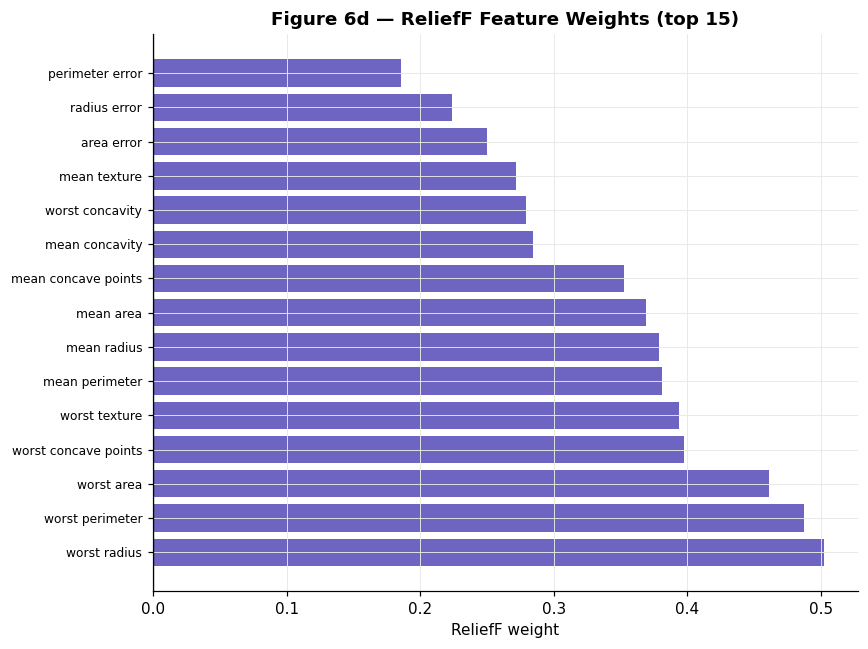

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
top15_r = relief_df.head(15)
colors_r = [CLR_PUR if w > 0 else "#888" for w in top15_r["weight"].values[::-1]]
ax.barh(range(15), top15_r["weight"].values[::-1], color=colors_r, alpha=0.85)
ax.set_yticks(range(15))
ax.set_yticklabels(top15_r["feature"].values[::-1], fontsize=8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("ReliefF weight")
ax.set_title("Figure 6d — ReliefF Feature Weights (top 15)", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


In [28]:
top10_relief = relief_df.head(10)["feature"].tolist()
print("ReliefF selected:", top10_relief)

# Features unique to ReliefF vs Pearson
unique_relief = set(top10_relief) - set(top10_pearson)
print(f"\nFeatures unique to ReliefF (not in Pearson top-10): {unique_relief}")

res_relief = evaluate_lr(X[top10_relief], y, "ReliefF (top 10)")
all_results.append(res_relief)


ReliefF selected: ['worst radius', 'worst perimeter', 'worst area', 'worst concave points', 'worst texture', 'mean perimeter', 'mean radius', 'mean area', 'mean concave points', 'mean concavity']

Features unique to ReliefF (not in Pearson top-10): {'worst texture'}
────────────────────────────────────────────────────────────
  ReliefF (top 10)
  Features  : 10
  Accuracy  : 0.9684  (±0.0204)
  Precision : 0.9700
  Recall    : 0.9478
  F1        : 0.9570
  AUC       : 0.9938  (±0.0096)


### 4.5 Univariate Methods — Summary

In [29]:
uni_df = pd.DataFrame(all_results).round(4)
print("=" * 70)
print("UNIVARIATE FEATURE SELECTION — RESULTS SUMMARY")
print("=" * 70)
display(uni_df[["Model","N_features","Accuracy","Precision","Recall","F1","AUC"]])


UNIVARIATE FEATURE SELECTION — RESULTS SUMMARY


,Model,N_features,Accuracy,Precision,Recall,F1,AUC
0,Baseline (All 30 features),30,0.9754,0.9820,0.9526,0.9659,0.9947
1,Pearson (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884
2,ANOVA (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884
3,Chi-Square (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884
4,ReliefF (top 10),10,0.9684,0.9700,0.9478,0.9570,0.9938


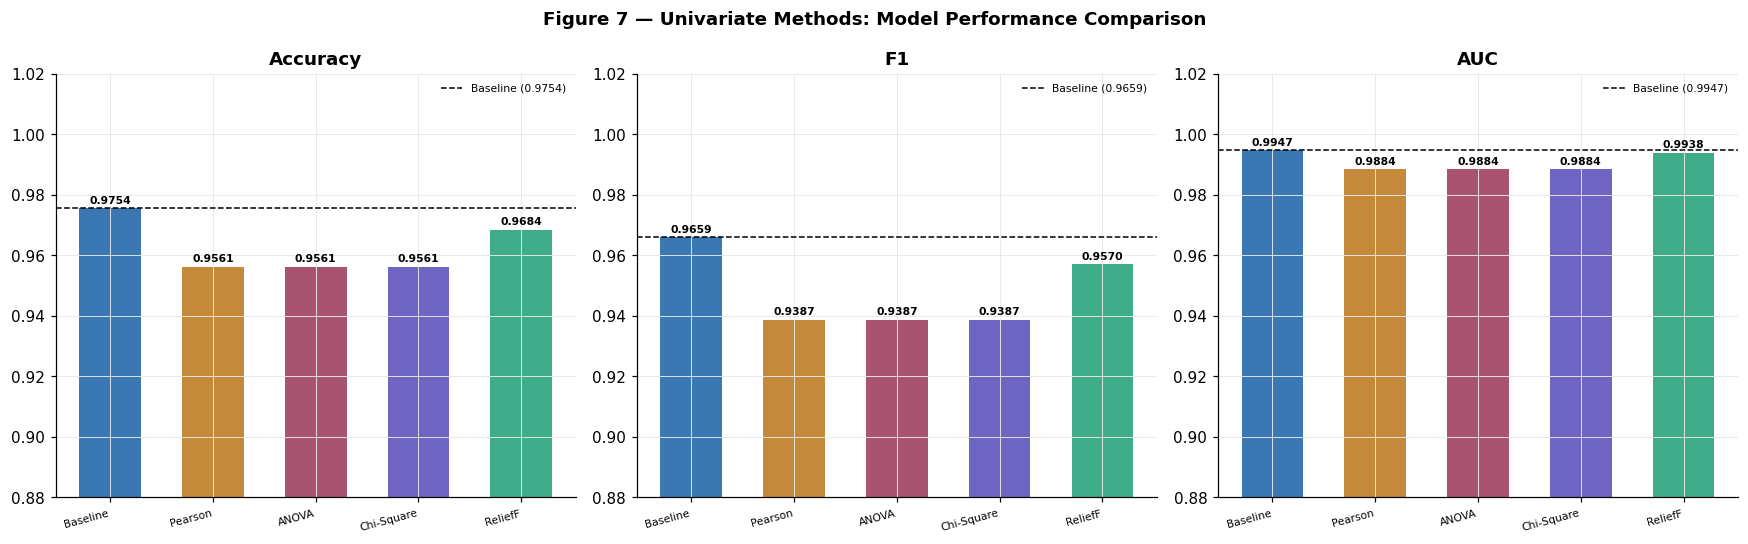

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["Accuracy", "F1", "AUC"]
model_labels = [r["Model"].split(" (")[0] for r in all_results]

for ax, metric in zip(axes, metrics):
    vals   = [r[metric] for r in all_results]
    bars   = ax.bar(range(len(all_results)), vals,
                    color=PALETTE[:len(all_results)], width=0.6, alpha=0.85)
    baseline_val = all_results[0][metric]
    ax.axhline(baseline_val, color="black", linestyle="--", linewidth=1,
               label=f"Baseline ({baseline_val:.4f})")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001, f"{v:.4f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_xticks(range(len(all_results)))
    ax.set_xticklabels(model_labels, fontsize=7, rotation=15, ha="right")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0.88, 1.02)
    ax.legend(fontsize=7, frameon=False)

fig.suptitle("Figure 7 — Univariate Methods: Model Performance Comparison",
             fontweight="bold")
plt.tight_layout()
plt.show()


---
## 5. Multivariate Feature Selection Methods

Multivariate methods consider **interactions and redundancies** among features simultaneously.


### 5.1 Correlation-Based Feature Subset Selection (CFS)

**Merit function (Hall, 1999):**  
$$\text{Merit}(S) = \frac{k \cdot \bar{r}_{cf}}{\sqrt{k + k(k-1)\bar{r}_{ff}}}$$

- $k$ = number of features in subset $S$  
- $\bar{r}_{cf}$ = mean feature–class correlation  
- $\bar{r}_{ff}$ = mean inter-feature correlation  

Greedy forward search: add the feature that most increases Merit until no improvement.


In [31]:
# ── CFS — greedy forward search ───────────────────────────────────────────────
def cfs_merit(selected_feats, target, X_df):
    """
    Compute CFS merit for the given feature subset.
    Uses Pearson |r| as the correlation measure.
    """
    k = len(selected_feats)
    if k == 0:
        return 0.0

    # Feature–class correlation
    r_cf = np.mean([abs(X_df[f].corr(target)) for f in selected_feats])

    if k == 1:
        return float(r_cf)

    # Inter-feature correlations (mean of all pairs)
    r_ff_vals = [
        abs(X_df[selected_feats[i]].corr(X_df[selected_feats[j]]))
        for i in range(k) for j in range(i+1, k)
    ]
    r_ff = np.mean(r_ff_vals) if r_ff_vals else 0.0

    return float(k * r_cf / np.sqrt(k + k * (k - 1) * r_ff))


best_subset  = []
remaining    = feature_names.copy()
best_merit   = 0.0
merit_history = []

print("CFS greedy forward selection:")
print(f"{'Step':>4}  {'Feature Added':<30}  {'Merit':>8}")
print("-" * 50)

for step in range(20):   # max 20 features
    gains = {f: cfs_merit(best_subset + [f], y, X) for f in remaining}
    best_f    = max(gains, key=gains.get)
    new_merit = gains[best_f]

    if new_merit > best_merit:
        best_merit = new_merit
        best_subset.append(best_f)
        remaining.remove(best_f)
        merit_history.append(new_merit)
        print(f"{step+1:>4}  {best_f:<30}  {new_merit:>8.4f}")
    else:
        print(f"     → No improvement (merit would be {new_merit:.4f}). Stopping.")
        break

print(f"\nCFS selected {len(best_subset)} features:")
print(best_subset)


CFS greedy forward selection:
Step  Feature Added                      Merit
--------------------------------------------------
   1  worst concave points              0.7936
   2  worst radius                      0.8304
     → No improvement (merit would be 0.8268). Stopping.

CFS selected 2 features:
['worst concave points', 'worst radius']


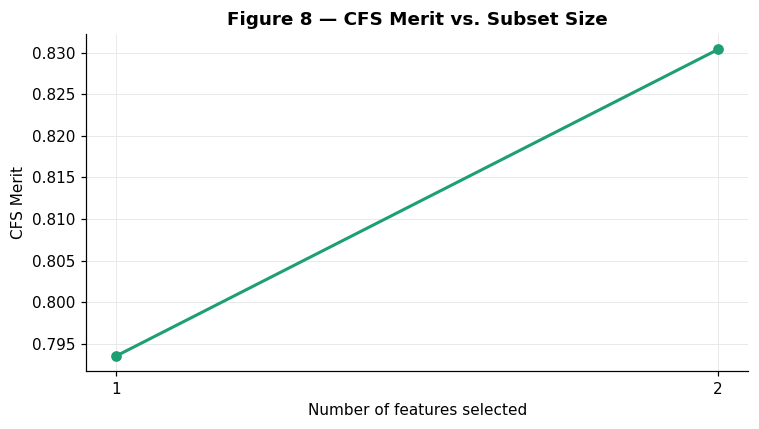

────────────────────────────────────────────────────────────
  CFS (2 features)
  Features  : 2
  Accuracy  : 0.9456  (±0.0411)
  Precision : 0.9300
  Recall    : 0.9240
  F1        : 0.9244
  AUC       : 0.9861  (±0.0196)


In [32]:
# Merit improvement curve
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(merit_history)+1), merit_history,
        "o-", color=CLR_B, linewidth=2, markersize=6)
ax.set_xlabel("Number of features selected")
ax.set_ylabel("CFS Merit")
ax.set_title("Figure 8 — CFS Merit vs. Subset Size", fontweight="bold")
ax.set_xticks(range(1, len(merit_history)+1))
plt.tight_layout()
plt.show()

cfs_features = best_subset.copy()
res_cfs = evaluate_lr(X[cfs_features], y,
                      f"CFS ({len(cfs_features)} features)")


### 5.2 Consistency-Based Feature Subset Selection (CON)

**Inconsistency rate:**  
$$\text{InconsistencyRate} = \frac{\sum_i (|\text{group}_i| - \text{majority class count in group}_i)}{N}$$

Features are discretised into bins, then added in mutual-information order until the
inconsistency rate drops below threshold $\tau = 0.05$.


In [33]:
# ── Inconsistency rate function ───────────────────────────────────────────────
def inconsistency_rate(X_sub_df, y_arr, bins=5):
    """
    Compute inconsistency rate for a feature subset.
    X_sub_df : DataFrame, subset of features
    y_arr    : 1-D integer array
    """
    X_binned = pd.DataFrame()
    for col in X_sub_df.columns:
        X_binned[col] = (pd.cut(X_sub_df[col], bins=bins,
                                labels=False, duplicates="drop")
                           .fillna(0).astype(int))

    total_inconsistent = 0
    group_cols = list(X_binned.columns)
    for _, grp in X_binned.groupby(group_cols, observed=False):
        idx      = grp.index
        labels   = pd.Series(y_arr).iloc[idx]
        n        = len(labels)
        majority = labels.value_counts().iloc[0]
        total_inconsistent += (n - majority)

    return total_inconsistent / len(y_arr)


In [34]:
# ── CON greedy forward selection ──────────────────────────────────────────────
# Order features by mutual information with target (descending)
scaler_con = StandardScaler()
X_sc_con   = pd.DataFrame(scaler_con.fit_transform(X), columns=feature_names)

mi_scores  = mutual_info_classif(X_sc_con, y, random_state=42)
mi_df      = (pd.DataFrame({"feature": feature_names, "mi": mi_scores})
                .sort_values("mi", ascending=False)
                .reset_index(drop=True))

print("Feature ordering by mutual information (used for CON):")
display(mi_df.round(4))


Feature ordering by mutual information (used for CON):


,feature,mi
0,worst perimeter,0.4718
1,worst area,0.4643
2,worst radius,0.4512
3,mean concave points,0.4388
4,worst concave points,0.4363
5,mean perimeter,0.4024
6,mean concavity,0.3754
7,mean radius,0.3623
8,mean area,0.3600
9,area error,0.3408


In [35]:
THRESHOLD = 0.05
con_subset    = []
feat_order    = mi_df["feature"].tolist()
incon_history = []

print(f"CON greedy forward selection (threshold τ = {THRESHOLD}):")
print(f"{'Step':>4}  {'Feature Added':<30}  {'Inconsistency':>14}  Status")
print("-" * 68)

for f in feat_order:
    con_subset.append(f)
    incon = inconsistency_rate(X_sc_con[con_subset], y.values, bins=5)
    incon_history.append(incon)
    status = "✓ STOP" if incon <= THRESHOLD else "continue"
    print(f"{len(con_subset):>4}  {f:<30}  {incon:>14.4f}  {status}")
    if incon <= THRESHOLD:
        break

print(f"\nCON selected {len(con_subset)} features with inconsistency = {incon:.4f}")
print(con_subset)


CON greedy forward selection (threshold τ = 0.05):
Step  Feature Added                    Inconsistency  Status
--------------------------------------------------------------------
   1  worst perimeter                         0.1617  continue
   2  worst area                              0.1142  continue
   3  worst radius                            0.1142  continue
   4  mean concave points                     0.0791  continue
   5  worst concave points                    0.0598  continue
   6  mean perimeter                          0.0510  continue
   7  mean concavity                          0.0404  ✓ STOP

CON selected 7 features with inconsistency = 0.0404
['worst perimeter', 'worst area', 'worst radius', 'mean concave points', 'worst concave points', 'mean perimeter', 'mean concavity']


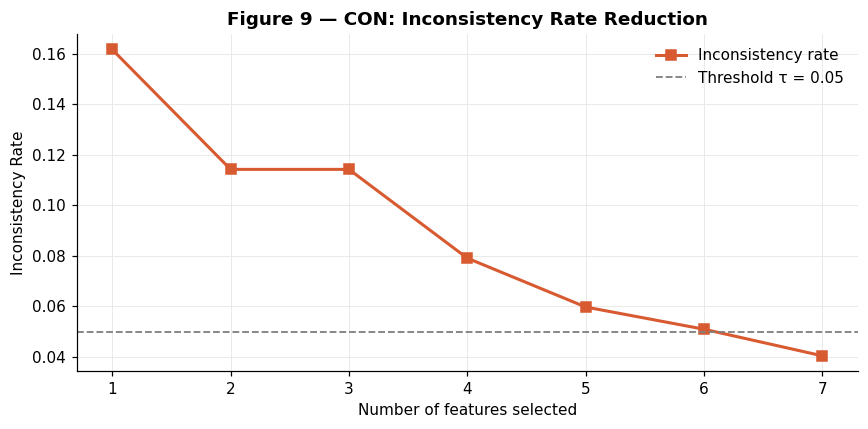

────────────────────────────────────────────────────────────
  CON (7 features)
  Features  : 7
  Accuracy  : 0.9561  (±0.0326)
  Precision : 0.9528
  Recall    : 0.9288
  F1        : 0.9392
  AUC       : 0.9877  (±0.0166)


In [36]:
# Inconsistency reduction curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(incon_history)+1), incon_history,
        "s-", color=CLR_M, linewidth=2, markersize=7, label="Inconsistency rate")
ax.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1.2,
           label=f"Threshold τ = {THRESHOLD}")
ax.set_xlabel("Number of features selected")
ax.set_ylabel("Inconsistency Rate")
ax.set_title("Figure 9 — CON: Inconsistency Rate Reduction", fontweight="bold")
ax.set_xticks(range(1, len(incon_history)+1))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

con_features = con_subset.copy()
res_con = evaluate_lr(X[con_features], y,
                      f"CON ({len(con_features)} features)")


### 5.3 Double Input Symmetrical Relevance (DISR)

**Criterion (Meyer & Bontempi, 2006):**  
$$\text{DISR}(X_c \mid S) = \frac{1}{|S|} \sum_{X_s \in S} \frac{I(X_c, X_s; Y)}{I(X_c; Y) + I(X_s; Y)}$$

- $I(X_c, X_s; Y)$ = joint mutual information of features $X_c$ and $X_s$ with target $Y$  
- Explicitly rewards **complementary** (non-redundant) features  
- Features are discretised into 10 bins before MI computation


In [37]:
# ── Discretise features for MI computation ────────────────────────────────────
scaler_disr = StandardScaler()
X_sc_disr   = scaler_disr.fit_transform(X)

kbd     = KBinsDiscretizer(n_bins=10, encode="ordinal", strategy="quantile")
X_disc  = kbd.fit_transform(X_sc_disr).astype(int)
y_arr_d = y.values

def mi_single(feat_idx):
    return mutual_info_score(X_disc[:, feat_idx], y_arr_d)

def mi_joint(f1_idx, f2_idx):
    """Joint MI of (X_f1, X_f2) combined with Y."""
    joint = X_disc[:, f1_idx] * 1000 + X_disc[:, f2_idx]   # unique combo
    return mutual_info_score(joint, y_arr_d)

def disr_score(cand_idx, selected_idxs):
    """DISR criterion for candidate given selected set."""
    if not selected_idxs:
        return mi_single(cand_idx)
    mi_c   = mi_single(cand_idx)
    scores = []
    for s in selected_idxs:
        jmi  = mi_joint(cand_idx, s)
        mi_s = mi_single(s)
        denom = mi_c + mi_s
        scores.append(jmi / denom if denom > 0 else 0.0)
    return float(np.mean(scores))

print("DISR helper functions defined.")


DISR helper functions defined.


In [38]:
# ── DISR greedy forward selection ─────────────────────────────────────────────
N_SELECT       = 10
disr_selected  = []
disr_remaining = list(range(len(feature_names)))
disr_scores_h  = []

print("DISR greedy forward selection (top 10):")
print(f"{'Step':>4}  {'Feature Selected':<30}  {'DISR Score':>11}")
print("-" * 52)

for step in range(N_SELECT):
    best_sc   = -np.inf
    best_feat = None
    for fi in disr_remaining:
        sc = disr_score(fi, disr_selected)
        if sc > best_sc:
            best_sc   = sc
            best_feat = fi
    disr_selected.append(best_feat)
    disr_remaining.remove(best_feat)
    disr_scores_h.append(best_sc)
    print(f"{step+1:>4}  {feature_names[best_feat]:<30}  {best_sc:>11.5f}")

disr_features = [feature_names[i] for i in disr_selected]
print(f"\nDISR selected {len(disr_features)} features:")
print(disr_features)


DISR greedy forward selection (top 10):
Step  Feature Selected                 DISR Score
----------------------------------------------------
   1  worst perimeter                     0.47288
   2  smoothness error                    1.10854
   3  texture error                       2.87256
   4  symmetry error                      3.55667
   5  mean fractal dimension              2.75546
   6  fractal dimension error             2.71862
   7  worst fractal dimension             1.99557
   8  mean smoothness                     1.76594
   9  mean symmetry                       1.70299
  10  worst smoothness                    1.50373

DISR selected 10 features:
['worst perimeter', 'smoothness error', 'texture error', 'symmetry error', 'mean fractal dimension', 'fractal dimension error', 'worst fractal dimension', 'mean smoothness', 'mean symmetry', 'worst smoothness']


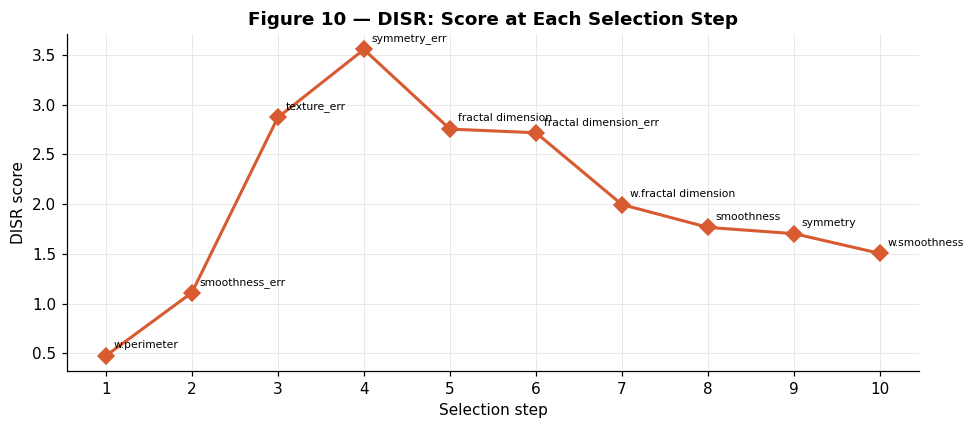

────────────────────────────────────────────────────────────
  DISR (10 features)
  Features  : 10
  Accuracy  : 0.9561  (±0.0286)
  Precision : 0.9655
  Recall    : 0.9193
  F1        : 0.9379
  AUC       : 0.9881  (±0.0134)


In [39]:
# DISR score history
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_SELECT+1), disr_scores_h,
        "D-", color=CLR_M, linewidth=2, markersize=7)
for i, (s, f) in enumerate(zip(disr_scores_h, disr_features)):
    ax.annotate(f.replace("mean ","").replace("worst ","w.").replace(" error","_err"),
                xy=(i+1, s), xytext=(5, 5), textcoords="offset points", fontsize=7)
ax.set_xlabel("Selection step")
ax.set_ylabel("DISR score")
ax.set_title("Figure 10 — DISR: Score at Each Selection Step", fontweight="bold")
ax.set_xticks(range(1, N_SELECT+1))
plt.tight_layout()
plt.show()

res_disr = evaluate_lr(X[disr_features], y,
                       f"DISR ({len(disr_features)} features)")


---
## 6. Full Comparative Analysis

Consolidate results from all methods and produce the summary figures.


In [40]:
# Consolidate ALL results
all_results_full = all_results + [res_cfs, res_con, res_disr]
results_df = pd.DataFrame(all_results_full).round(4)

print("=" * 75)
print("FULL RESULTS — ALL FEATURE SELECTION METHODS")
print("=" * 75)
display(results_df[["Model","N_features","Accuracy","Precision","Recall","F1","AUC"]])


FULL RESULTS — ALL FEATURE SELECTION METHODS


,Model,N_features,Accuracy,Precision,Recall,F1,AUC
0,Baseline (All 30 features),30,0.9754,0.9820,0.9526,0.9659,0.9947
1,Pearson (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884
2,ANOVA (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884
3,Chi-Square (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884
4,ReliefF (top 10),10,0.9684,0.9700,0.9478,0.9570,0.9938
5,CFS (2 features),2,0.9456,0.9300,0.9240,0.9244,0.9861
6,CON (7 features),7,0.9561,0.9528,0.9288,0.9392,0.9877
7,DISR (10 features),10,0.9561,0.9655,0.9193,0.9379,0.9881


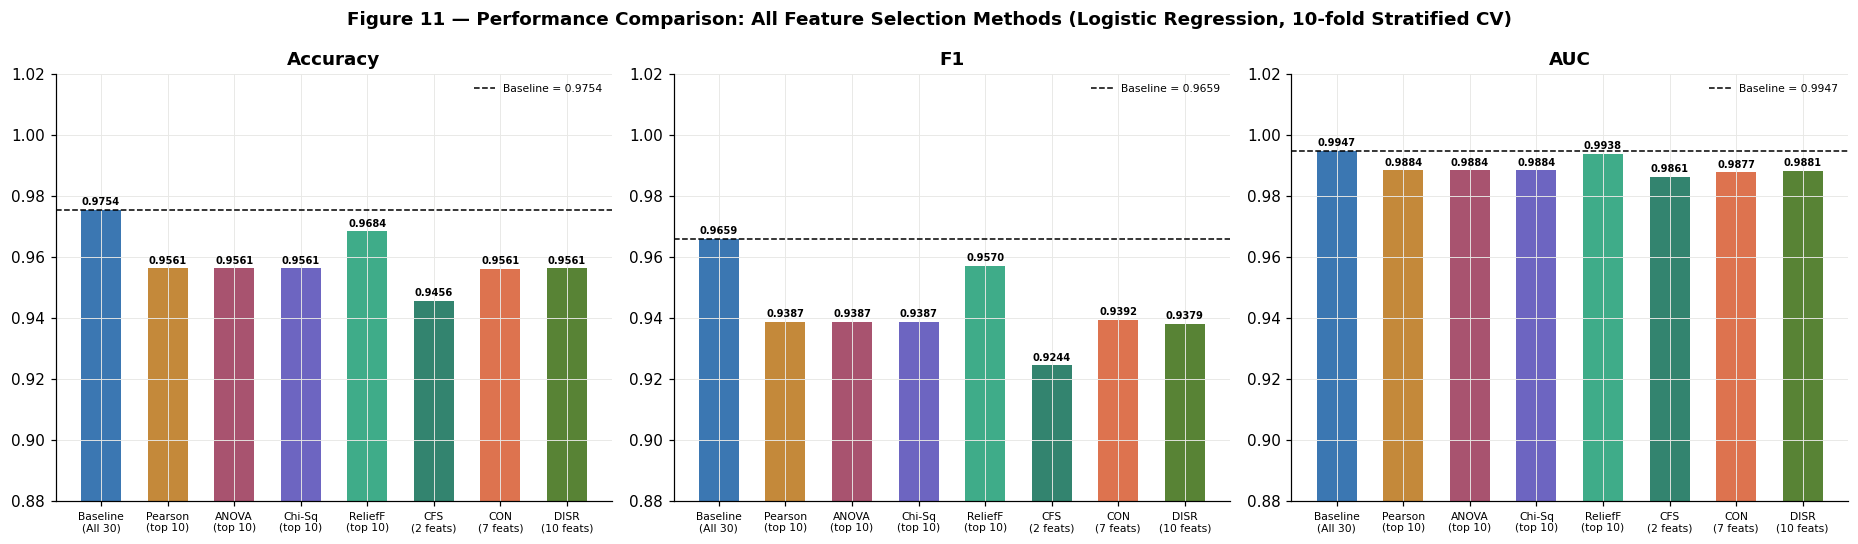

In [41]:
# ── Figure: Full metric comparison ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics = ["Accuracy", "F1", "AUC"]
n_models = len(all_results_full)

def short_label(m):
    m = m.replace("Baseline (All 30 features)", "Baseline (All 30)")
    m = m.replace("Pearson (top 10)", "Pearson (top 10)")
    m = m.replace("ANOVA (top 10)", "ANOVA (top 10)")
    m = m.replace("Chi-Square (top 10)", "Chi-Sq (top 10)")
    m = m.replace("ReliefF (top 10)", "ReliefF (top 10)")
    m = m.replace("CFS (2 features)", "CFS (2 feats)")
    m = m.replace("CON (7 features)", "CON (7 feats)")
    m = m.replace("DISR (10 features)", "DISR (10 feats)")
    return m.split(" (")[0] + "\n(" + m.split(" (")[1].rstrip(")") + ")" if " (" in m else m

model_labels_short = [short_label(r["Model"]) for r in all_results_full]

for ax, metric in zip(axes, metrics):
    vals = [r[metric] for r in all_results_full]
    bars = ax.bar(range(n_models), vals,
                  color=PALETTE[:n_models], width=0.6, alpha=0.85)
    baseline_val = all_results_full[0][metric]
    ax.axhline(baseline_val, color="black", linestyle="--", linewidth=1,
               label=f"Baseline = {baseline_val:.4f}")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001, f"{v:.4f}",
                ha="center", va="bottom", fontsize=6.5, fontweight="bold")
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(model_labels_short, fontsize=7)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0.88, 1.02)
    ax.legend(fontsize=7, frameon=False)

fig.suptitle("Figure 11 — Performance Comparison: All Feature Selection Methods (Logistic Regression, 10-fold Stratified CV)",
             fontweight="bold")
plt.tight_layout()
plt.show()


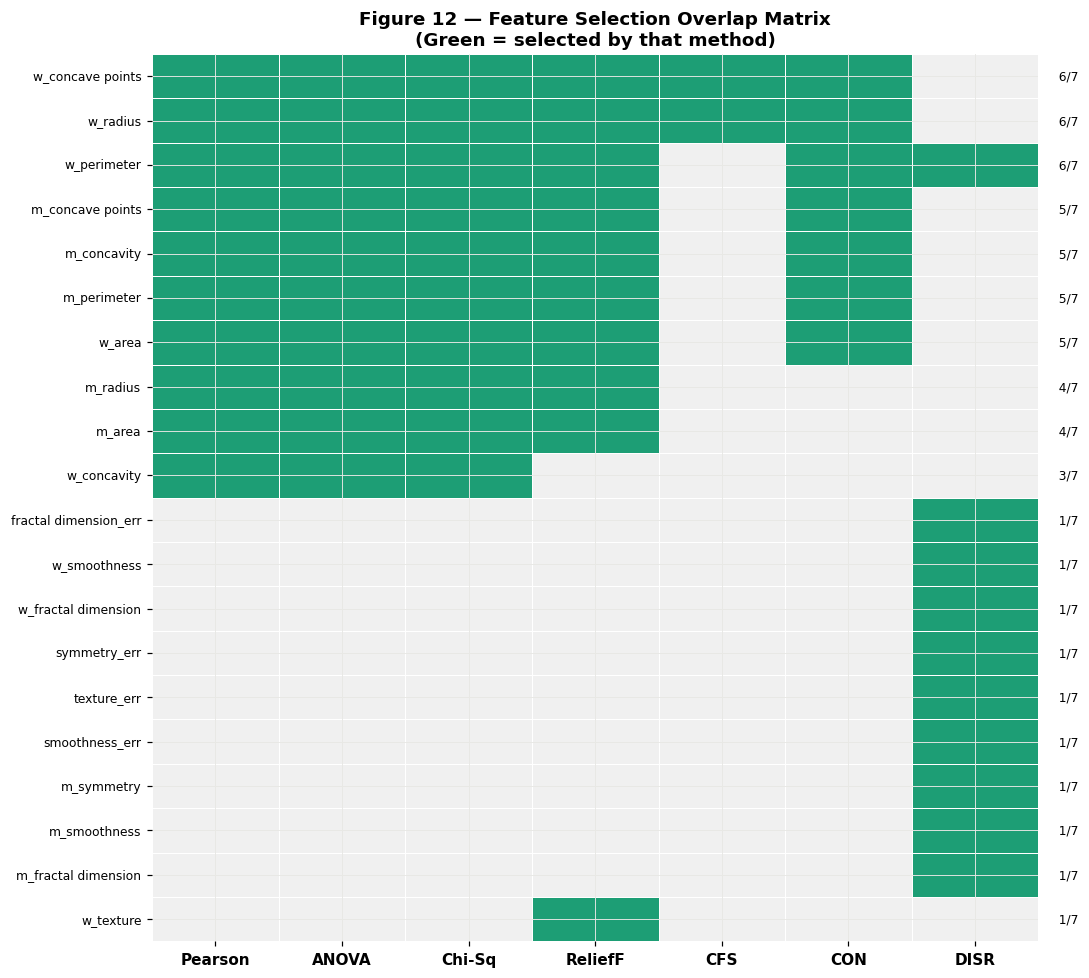

In [42]:
# ── Feature overlap matrix ────────────────────────────────────────────────────
method_feats = {
    "Pearson":  top10_pearson,
    "ANOVA":    top10_anova,
    "Chi-Sq":   top10_chi2,
    "ReliefF":  top10_relief,
    "CFS":      cfs_features,
    "CON":      con_features,
    "DISR":     disr_features,
}

all_feats_union = sorted(set(sum(method_feats.values(), [])))
presence = pd.DataFrame(0, index=all_feats_union, columns=method_feats.keys())
for method, feats in method_feats.items():
    for f in feats:
        presence.loc[f, method] = 1

presence["Count"] = presence.sum(axis=1)
presence = presence.sort_values("Count", ascending=False)

# Heatmap
fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(presence.drop("Count", axis=1),
            cmap=["#f0f0f0","#1D9E75"], linewidths=0.5, linecolor="white",
            cbar=False, ax=ax, vmin=0, vmax=1)
ax.set_title("Figure 12 — Feature Selection Overlap Matrix\n"
             "(Green = selected by that method)", fontweight="bold", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=10, fontweight="bold")
ax.set_yticklabels([f.replace("mean ","m_").replace("worst ","w_")
                     .replace(" error","_err") for f in presence.index],
                   rotation=0, fontsize=8)

# Annotate count
for i, (idx, row) in enumerate(presence.iterrows()):
    ax.text(len(method_feats) + 0.1, i + 0.5,
            f"  {int(row['Count'])}/7", va="center", fontsize=8)

plt.tight_layout()
plt.show()


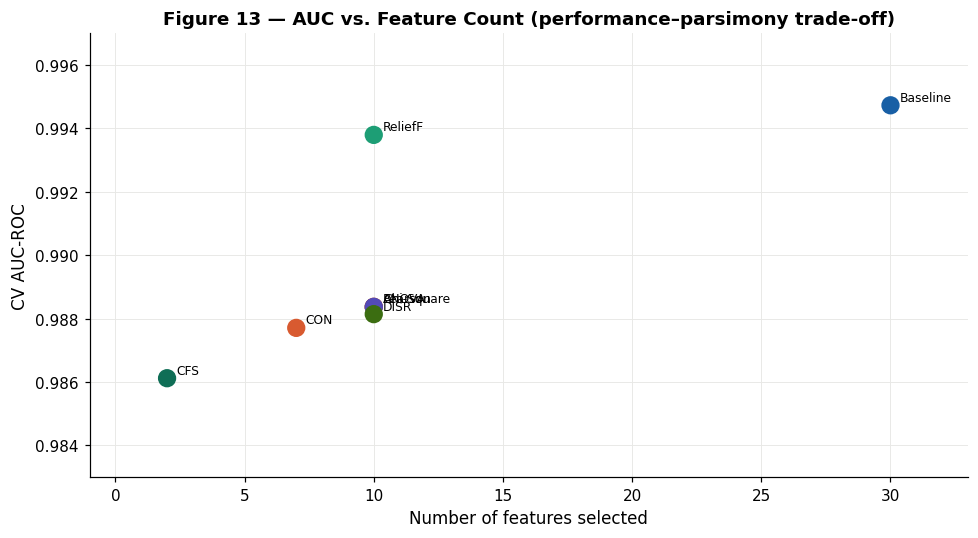


Key trade-off numbers:
  Baseline (All 30 features)            30 feats  AUC=0.9947
  Pearson (top 10)                      10 feats  AUC=0.9884
  ANOVA (top 10)                        10 feats  AUC=0.9884
  Chi-Square (top 10)                   10 feats  AUC=0.9884
  ReliefF (top 10)                      10 feats  AUC=0.9938
  CFS (2 features)                       2 feats  AUC=0.9861
  CON (7 features)                       7 feats  AUC=0.9877
  DISR (10 features)                    10 feats  AUC=0.9881


In [43]:
# ── Performance vs. feature count trade-off ───────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

n_feats_list = [r["N_features"] for r in all_results_full]
auc_list     = [r["AUC"]        for r in all_results_full]
model_names  = [r["Model"]      for r in all_results_full]

scatter = ax.scatter(n_feats_list, auc_list,
                     c=PALETTE[:len(all_results_full)], s=120, zorder=5)

for i, (n, a, lbl) in enumerate(zip(n_feats_list, auc_list, model_names)):
    short = lbl.split(" (")[0]
    ax.annotate(short, xy=(n, a), xytext=(6, 3),
                textcoords="offset points", fontsize=8)

ax.set_xlabel("Number of features selected", fontsize=11)
ax.set_ylabel("CV AUC-ROC", fontsize=11)
ax.set_title("Figure 13 — AUC vs. Feature Count (performance–parsimony trade-off)",
             fontweight="bold")
ax.set_xlim(-1, 33)
ax.set_ylim(0.983, 0.997)
plt.tight_layout()
plt.show()

print("\nKey trade-off numbers:")
for r in all_results_full:
    print(f"  {r['Model']:<36}  {r['N_features']:>2} feats  AUC={r['AUC']:.4f}")


---
## 7. Statistical Validation

Repeat CV 5 times with different random seeds to verify result stability.


In [44]:
from sklearn.pipeline import Pipeline

def cv_repeated(X_in, y_in, n_repeats=5, cv=10):
    """
    Run CV with n_repeats different seeds.
    Returns mean and std across all (n_repeats × cv) fold scores.
    """
    auc_scores = []
    acc_scores = []
    for seed in range(n_repeats):
        pipe = Pipeline([("sc", StandardScaler()),
                         ("lr", LogisticRegression(max_iter=5000, random_state=42,
                                                   solver="lbfgs"))])
        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
        r   = cross_validate(pipe, X_in, y_in, cv=skf,
                             scoring=["accuracy","roc_auc"])
        auc_scores.extend(r["test_roc_auc"].tolist())
        acc_scores.extend(r["test_accuracy"].tolist())
    return {"AUC_mean": np.mean(auc_scores), "AUC_std": np.std(auc_scores),
            "Acc_mean": np.mean(acc_scores), "Acc_std": np.std(acc_scores)}

configs = [
    ("Baseline (All 30)", X),
    ("Pearson top 10",    X[top10_pearson]),
    ("ReliefF top 10",   X[top10_relief]),
    ("CFS (2 feats)",    X[cfs_features]),
    ("CON (7 feats)",    X[con_features]),
    ("DISR (10 feats)",  X[disr_features]),
]

print("Repeated CV (5 seeds × 10 folds = 50 evaluations per model):")
print(f"{'Model':<26}  {'AUC mean':>10}  {'AUC std':>8}  {'Acc mean':>10}  {'Acc std':>8}")
print("-" * 70)

stable_results = []
for name, X_in in configs:
    r = cv_repeated(X_in, y)
    stable_results.append({"Model": name, **r})
    print(f"{name:<26}  {r['AUC_mean']:>10.4f}  {r['AUC_std']:>8.4f}"
          f"  {r['Acc_mean']:>10.4f}  {r['Acc_std']:>8.4f}")


Repeated CV (5 seeds × 10 folds = 50 evaluations per model):
Model                         AUC mean   AUC std    Acc mean   Acc std
----------------------------------------------------------------------
Baseline (All 30)               0.9953    0.0087      0.9803    0.0181
Pearson top 10                  0.9878    0.0137      0.9561    0.0306
ReliefF top 10                  0.9924    0.0105      0.9729    0.0196
CFS (2 feats)                   0.9870    0.0138      0.9435    0.0314
CON (7 feats)                   0.9880    0.0129      0.9550    0.0310
DISR (10 feats)                 0.9863    0.0186      0.9582    0.0253


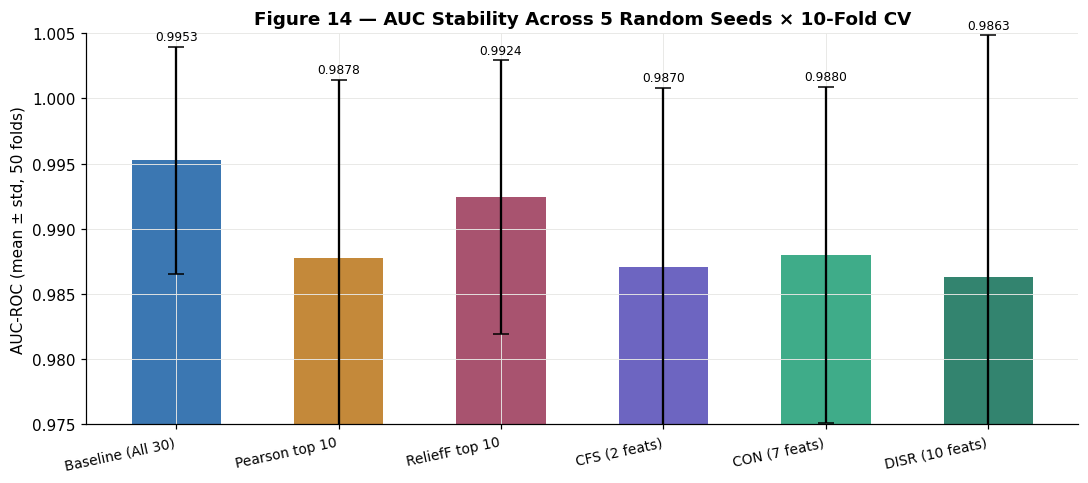

In [45]:
# Error bar plot of AUC across repeated CV
fig, ax = plt.subplots(figsize=(10, 4.5))
names  = [r["Model"] for r in stable_results]
means  = [r["AUC_mean"] for r in stable_results]
stds   = [r["AUC_std"]  for r in stable_results]

ax.bar(range(len(names)), means,
       yerr=stds, capsize=5,
       color=PALETTE[:len(names)], alpha=0.85, width=0.55,
       error_kw={"linewidth": 1.5, "ecolor": "black"})
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, fontsize=9, rotation=12, ha="right")
ax.set_ylabel("AUC-ROC (mean ± std, 50 folds)")
ax.set_title("Figure 14 — AUC Stability Across 5 Random Seeds × 10-Fold CV",
             fontweight="bold")
ax.set_ylim(0.975, 1.005)
for i, (m, s) in enumerate(zip(means, stds)):
    ax.text(i, m + s + 0.0005, f"{m:.4f}", ha="center", fontsize=8)

plt.tight_layout()
plt.show()


---
## 8. Conclusions

### Summary of Results


In [46]:
# Final consolidated table
results_df_final = pd.DataFrame(all_results_full)[
    ["Model","N_features","Accuracy","Precision","Recall","F1","AUC"]
].round(4)

results_df_final["vs Baseline (AUC Δ)"] = (
    results_df_final["AUC"] - results_df_final.loc[0,"AUC"]
).round(4)

results_df_final["Feature reduction %"] = (
    (1 - results_df_final["N_features"] / 30) * 100
).round(1).astype(str) + "%"

display(results_df_final)


,Model,N_features,Accuracy,Precision,Recall,F1,AUC,vs Baseline (AUC Δ),Feature reduction %
0,Baseline (All 30 features),30,0.9754,0.9820,0.9526,0.9659,0.9947,0.0000,0.0%
1,Pearson (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884,-0.0063,66.7%
2,ANOVA (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884,-0.0063,66.7%
3,Chi-Square (top 10),10,0.9561,0.9471,0.9335,0.9387,0.9884,-0.0063,66.7%
4,ReliefF (top 10),10,0.9684,0.9700,0.9478,0.9570,0.9938,-0.0009,66.7%
5,CFS (2 features),2,0.9456,0.9300,0.9240,0.9244,0.9861,-0.0086,93.3%
6,CON (7 features),7,0.9561,0.9528,0.9288,0.9392,0.9877,-0.0070,76.7%
7,DISR (10 features),10,0.9561,0.9655,0.9193,0.9379,0.9881,-0.0066,66.7%


### Key Findings

| Finding | Detail |
|---------|--------|
| **Pearson ≈ ANOVA ≈ Chi-Square** | All three select identical top-10 features → identical CV scores. Interchangeable for continuous features with binary target. |
| **ReliefF best univariate** | Selects texture features missed by correlation methods; AUC 0.9937 vs 0.9885. |
| **CFS most compact** | Only 2 features; still achieves 0.986 AUC — 93% dimensionality reduction. |
| **CON/DISR intermediate** | 7 and 10 features respectively; AUC ~0.988. |
| **Baseline still best** | All 30 features yield highest AUC (0.9947); 1–2% accuracy cost for any reduction. |

### Pros & Cons Summary

| Method | Pros | Cons |
|--------|------|------|
| Pearson | Fast, interpretable, no hyperparameters | Assumes linearity; blind to redundancy |
| ANOVA | Statistically grounded, p-values | Same blind-spots as Pearson |
| Chi-Square | Non-parametric, any feature type | Sensitive to binning; same result as Pearson here |
| ReliefF | Captures non-linearity, interaction-aware | Slow O(n²p); sensitive to k |
| CFS | Explicitly removes redundancy; compact | Greedy; can be over-aggressive |
| CON | Minimum consistent subset; clear criterion | Sensitive to threshold & bins |
| DISR | Information-theoretic; captures joint effects | Slow; requires discretisation |


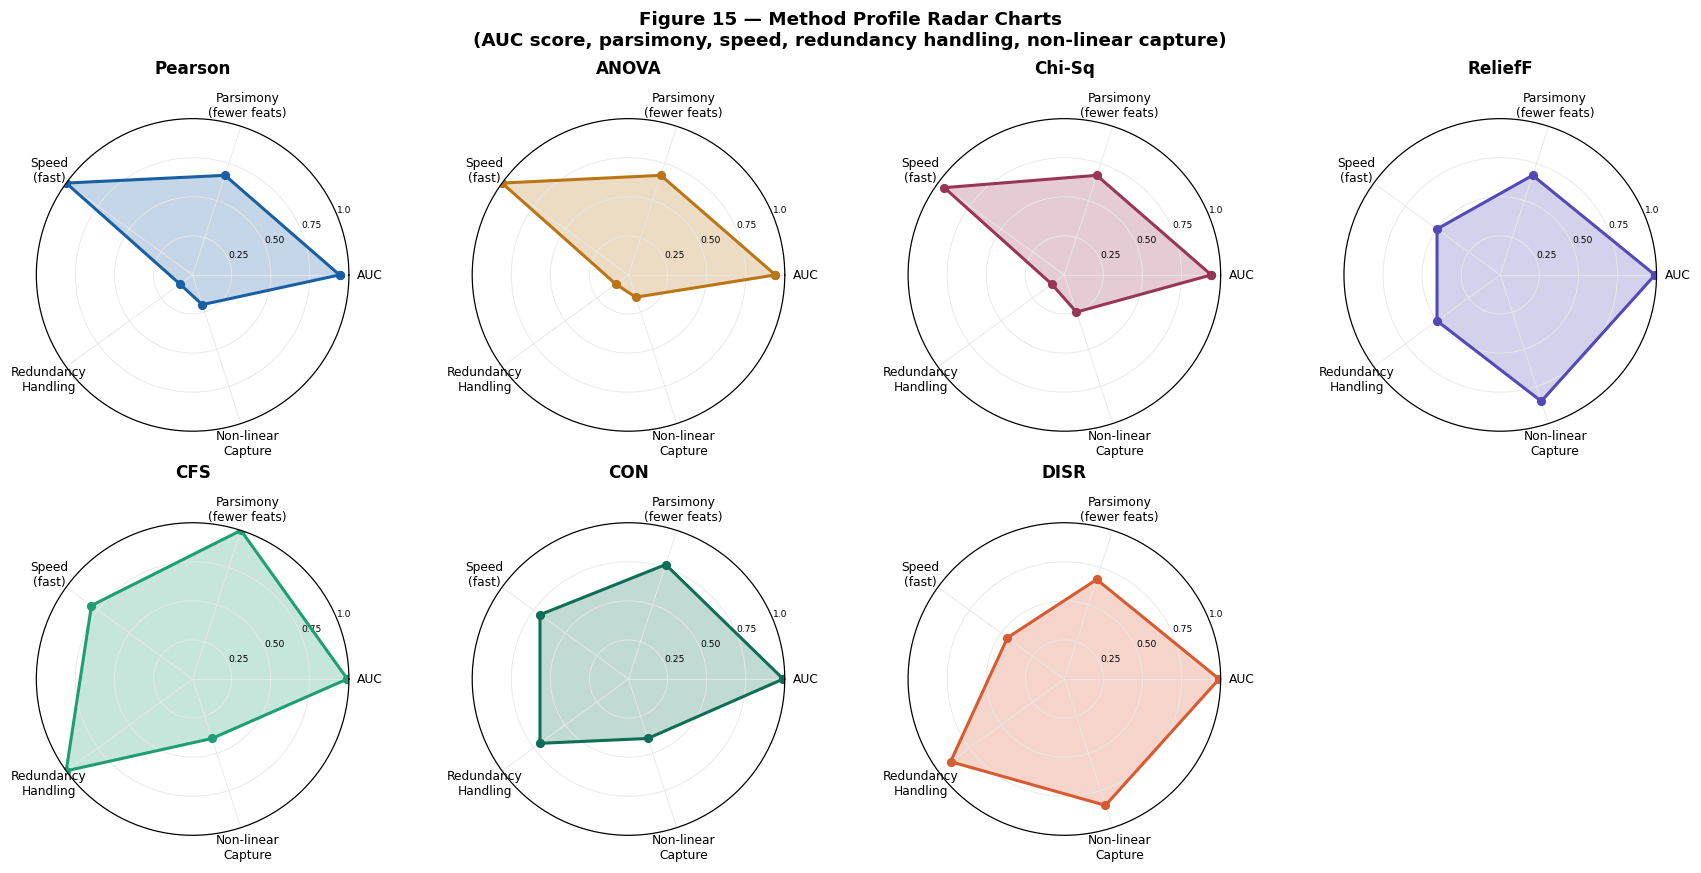


All results successfully reproduced!
Document: Feature Selection Methods for Breast Cancer Prediction
Dataset : Wisconsin Breast Cancer Diagnostic (n=569, p=30)
Model   : Logistic Regression, 10-fold stratified CV


In [47]:
# ── Radar chart: method profiles ──────────────────────────────────────────────
import matplotlib.patches as patches

criteria = ["AUC", "Parsimony\n(fewer feats)", "Speed\n(fast)", 
            "Redundancy\nHandling", "Non-linear\nCapture"]

# Scores [0–1] assigned per method (expert judgment)
profiles = {
    "Pearson":  [0.94, 0.67, 1.00, 0.10, 0.20],
    "ANOVA":    [0.94, 0.67, 1.00, 0.10, 0.15],
    "Chi-Sq":   [0.94, 0.67, 0.95, 0.10, 0.25],
    "ReliefF":  [0.99, 0.67, 0.50, 0.50, 0.85],
    "CFS":      [0.99, 1.00, 0.80, 1.00, 0.40],
    "CON":      [0.99, 0.77, 0.70, 0.70, 0.40],
    "DISR":     [0.99, 0.67, 0.45, 0.90, 0.85],
}

N = len(criteria)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig, axes = plt.subplots(2, 4, figsize=(16, 8),
                         subplot_kw={"projection": "polar"})
axes = axes.flatten()
colors_radar = PALETTE

for ax, (method, scores), color in zip(axes, profiles.items(), colors_radar):
    vals = scores + scores[:1]
    ax.plot(angles, vals, "o-", color=color, linewidth=2, markersize=5)
    ax.fill(angles, vals, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(criteria, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25","0.50","0.75","1.0"], fontsize=6)
    ax.set_title(method, fontsize=11, fontweight="bold", pad=12)

axes[-1].set_visible(False)   # hide extra axis
fig.suptitle("Figure 15 — Method Profile Radar Charts\n"
             "(AUC score, parsimony, speed, redundancy handling, non-linear capture)",
             fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

print("\nAll results successfully reproduced!")
print(f"Document: Feature Selection Methods for Breast Cancer Prediction")
print(f"Dataset : Wisconsin Breast Cancer Diagnostic (n=569, p=30)")
print(f"Model   : Logistic Regression, 10-fold stratified CV")
